## Тестируем алгоритмы бустинга

### Окружение

Датасет: [Telco Customer Churn](https://www.kaggle.com/blastchar/telco-customer-churn) — предсказание оттока клиентов телеком-оператора.


In [1]:
%pip install -q numpy pandas scikit-learn matplotlib seaborn xgboost lightgbm catboost

### Загрузка данных

In [2]:
from pathlib import Path
from urllib.request import urlretrieve

# Публичное зеркало IBM: качается без Kaggle-токена, поэтому ноутбук воспроизводим.
URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

# Путь относительный: рабочая директория ядра — папка с ноутбуком.
DATA_PATH = Path("data") / "Telco-Customer-Churn.csv"

if DATA_PATH.exists():
    print(f"Файл уже на месте: {DATA_PATH} ({DATA_PATH.stat().st_size / 1024:.0f} КБ)")
else:
    DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
    urlretrieve(URL, DATA_PATH)
    print(f"Скачано: {DATA_PATH} ({DATA_PATH.stat().st_size / 1024:.0f} КБ)")

Файл уже на месте: data/Telco-Customer-Churn.csv (948 КБ)


## EDA

### Первичный осмотр

In [3]:
import pandas as pd

df = pd.read_csv(DATA_PATH)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
# describe() по умолчанию берёт только числовые колонки — здесь это 3 из 21.
# .T — иначе 18 колонок не читаются по ширине.
df.describe(include="str").T

,count,unique,top,freq
customerID,7043,7043,7590-VHVEG,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


### Шаг 1. Скрытые пропуски в `TotalCharges`

`info()` не показал ни одного `NaN`, но `TotalCharges` имеет строковый тип, хотя содержит деньги. Ищем, что мешает колонке быть числовой.

In [ ]:
df[pd.to_numeric(df['TotalCharges'], errors='coerce').isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [8]:
# У всех 11 строк выше tenure == 0. Проверяем, что это не совпадение,
# а строгое двустороннее соответствие: пусто тогда и только тогда, когда tenure == 0.
total_num = pd.to_numeric(df["TotalCharges"], errors="coerce")
blank = total_num.isna()
zero_tenure = df["tenure"] == 0

print(f"пустых TotalCharges         : {blank.sum()}")
print(f"строк с tenure == 0         : {zero_tenure.sum()}")
print(f"пересечение                 : {(blank & zero_tenure).sum()}")
print(f"маски совпадают полностью   : {(blank == zero_tenure).all()}")
print(f"что лежит в 'пустых'        : {df.loc[blank, 'TotalCharges'].unique().tolist()!r}")

пустых TotalCharges         : 11
строк с tenure == 0         : 11
пересечение                 : 11
маски совпадают полностью   : True
что лежит в 'пустых'        : [' ']


### Шаг 2. Дубликаты строк

`customerID` уникален у всех 7043 клиентов, поэтому `df.duplicated()` по всем колонкам возвращает 0 по построению. Ищем дубликаты по набору признаков без идентификатора и отдельно смотрим, согласован ли у близнецов таргет.

In [9]:
X_COLS = [c for c in df.columns if c not in ("customerID", "Churn")]

groups = df.groupby(X_COLS, dropna=False, observed=True)["Churn"].agg(n="size", uniq="nunique")

dup = groups[groups["n"] > 1]           # группы строк с идентичными признаками
conflict = groups[groups["uniq"] > 1]   # из них те, где Churn различается

print(f"дубли по всем колонкам (с customerID): {df.duplicated().sum()}  <- тавтология")
print(f"групп-близнецов по 20 признакам     : {len(dup):3d} | строк в них: {int(dup['n'].sum())}")
print(f"из них с противоречивым Churn       : {len(conflict):3d} | строк в них: {int(conflict['n'].sum())}")

дубли по всем колонкам (с customerID): 0  <- тавтология
групп-близнецов по 20 признакам     :  33 | строк в них: 73
из них с противоречивым Churn       :  18 | строк в них: 42


### Шаг 3. Избыточность категорий

Шесть колонок услуг (`OnlineSecurity` … `StreamingMovies`) имеют три категории вместо ожидаемых двух: третья — `No internet service`. Проверяем гипотезу, что это не самостоятельный ответ, а повторение факта `InternetService == 'No'`. Аналогично для `No phone service` в `MultipleLines`.

In [10]:
NET_SERVICES = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
                "TechSupport", "StreamingTV", "StreamingMovies"]

# Сравниваем маски целиком, а не только пересечение: это проверка «тогда и только тогда».
no_net = df["InternetService"] == "No"
print(f"клиентов без интернета (InternetService == 'No'): {no_net.sum()}")
for c in NET_SERVICES:
    marker = df[c] == "No internet service"
    print(f"  {c:18} маркеров: {marker.sum():4d} | маска совпадает: {(marker == no_net).all()}")

no_phone = df["PhoneService"] == "No"
marker = df["MultipleLines"] == "No phone service"
print(f"\nклиентов без телефона (PhoneService == 'No'):   {no_phone.sum()}")
print(f"  {'MultipleLines':18} маркеров: {marker.sum():4d} | маска совпадает: {(marker == no_phone).all()}")

клиентов без интернета (InternetService == 'No'): 1526
  OnlineSecurity     маркеров: 1526 | маска совпадает: True
  OnlineBackup       маркеров: 1526 | маска совпадает: True
  DeviceProtection   маркеров: 1526 | маска совпадает: True
  TechSupport        маркеров: 1526 | маска совпадает: True
  StreamingTV        маркеров: 1526 | маска совпадает: True
  StreamingMovies    маркеров: 1526 | маска совпадает: True

клиентов без телефона (PhoneService == 'No'):   682
  MultipleLines      маркеров:  682 | маска совпадает: True


### Шаг 4. Баланс классов

Смотрим, как часто встречается отток. От этого зависит выбор метрики: при сильном перекосе доля правильных ответов (accuracy) перестаёт что-либо измерять.

In [11]:
counts = df["Churn"].value_counts()

balance = pd.DataFrame({
    "клиентов": counts,
    "доля, %": (counts / len(df) * 100).round(2),
})
print(balance.to_string())

print(f"\nсоотношение классов          : 1 к {counts['No'] / counts['Yes']:.2f}")
# Модель, всегда отвечающая "не уйдёт", не находит ни одного оттока,
# но формально угадывает долю, равную доле большего класса.
print(f"accuracy у модели «всегда No»: {counts['No'] / len(df):.4f}")

       клиентов  доля, %
Churn                   
No         5174    73.46
Yes        1869    26.54

соотношение классов          : 1 к 2.77
accuracy у модели «всегда No»: 0.7346


### Шаг 5. Корреляция числовых признаков

Корреляция Пирсона применима только к числовым признакам, поэтому здесь участвуют лишь `tenure`, `MonthlyCharges` и `TotalCharges` — связь категорий с оттоком смотрим отдельно дальше.

Проверяем подозрение, возникшее в Шаге 1: не является ли `TotalCharges` просто произведением двух других колонок. Слева — матрица корреляций, справа — прямая проверка гипотезы.

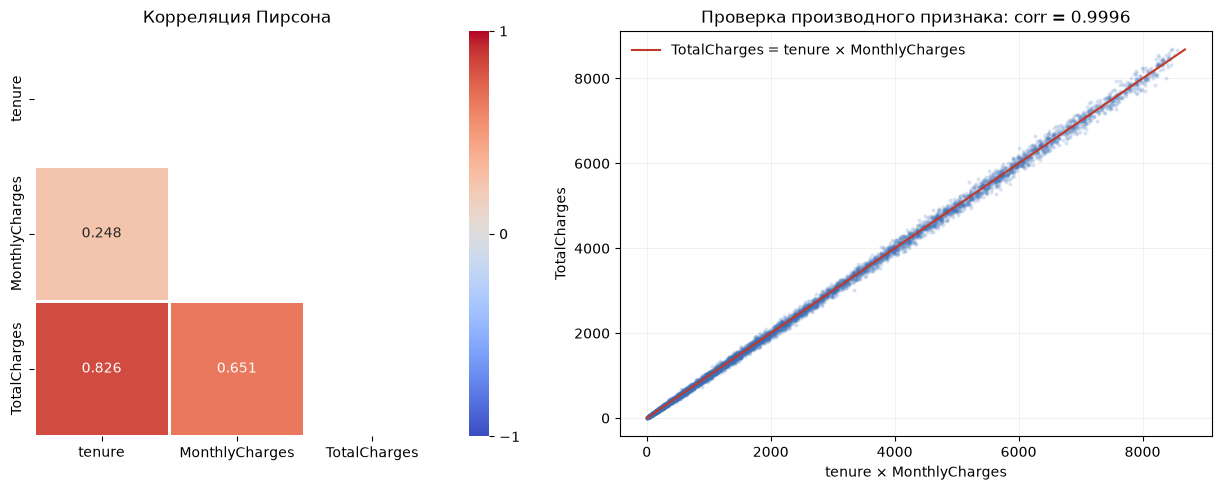

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TotalCharges всё ещё строковый — приводим к числу локально, только для расчёта.
# Пропуски (ровно строки с tenure == 0) заполняем нулём: по формуле
# tenure * MonthlyCharges накопленная сумма у них и должна быть нулевой.
num = df[["tenure", "MonthlyCharges"]].copy()
num["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)
product = df["tenure"] * df["MonthlyCharges"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

corr = num.corr()
# Прячем диагональ и верхний треугольник: единицы на диагонали смысла не несут,
# но красятся в самый насыщенный цвет и перетягивают внимание, а верхний
# треугольник дублирует нижний. Остаются ровно три информативные ячейки.
mask = np.triu(np.ones_like(corr, dtype=bool))

# vmin/vmax заданы жёстко: иначе палитра растянется по фактическому диапазону,
# нейтральный цвет уедет из нуля и слабая корреляция будет выглядеть сильной.
sns.heatmap(corr, mask=mask, annot=True, fmt=".3f", cmap="coolwarm", vmin=-1, vmax=1,
            square=True, linewidths=2, linecolor="white",
            cbar_kws={"ticks": [-1, 0, 1]}, ax=axes[0])
axes[0].set_title("Корреляция Пирсона")

axes[1].scatter(product, num["TotalCharges"], s=8, alpha=0.20,
                color="#3b6fb6", linewidths=0)
lim = max(product.max(), num["TotalCharges"].max())
axes[1].plot([0, lim], [0, lim], color="#c0392b", lw=1.5,
             label="TotalCharges = tenure × MonthlyCharges")
axes[1].set_xlabel("tenure × MonthlyCharges")
axes[1].set_ylabel("TotalCharges")
axes[1].set_title(f"Проверка производного признака: corr = {num['TotalCharges'].corr(product):.4f}")
axes[1].legend(loc="upper left", frameon=False)
axes[1].grid(alpha=0.25, linewidth=0.5)
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.show()

### Шаг 6. Распределения и связь признаков с оттоком

Две задачи. Первая — числовые признаки: посмотреть форму распределений и понять, отличаются ли ушедшие клиенты от оставшихся. Заодно проверяем, нет ли невозможных значений (отрицательных сумм, срока больше 72 месяцев).

Про выбросы отдельно: искать и удалять их здесь не вижу смысла. Дерево делит выборку по правилу "признак больше или меньше порога", ему важен только порядок значений, а не их удалённость от остальных. Бустинг инвариантен к монотонным преобразованиям признаков, поэтому логарифмирование или обрезание хвостов не изменят ни одного разбиения. Это приём для линейных и метрических моделей, а не для нашего случая. Вдобавок `TotalCharges = 8684` — это законные 72 месяца по дорогому тарифу, и удалять такого клиента как "выброс" значило бы выбросить самого ценного.

Вторая задача — категориальные признаки. Корреляция Пирсона к ним неприменима, поэтому связь с таргетом меряем прямо: считаем **долю ушедших внутри каждой категории** и сравниваем с общим уровнем 26,5%. Чем сильнее категории признака расходятся между собой, тем больше в нём сигнала.

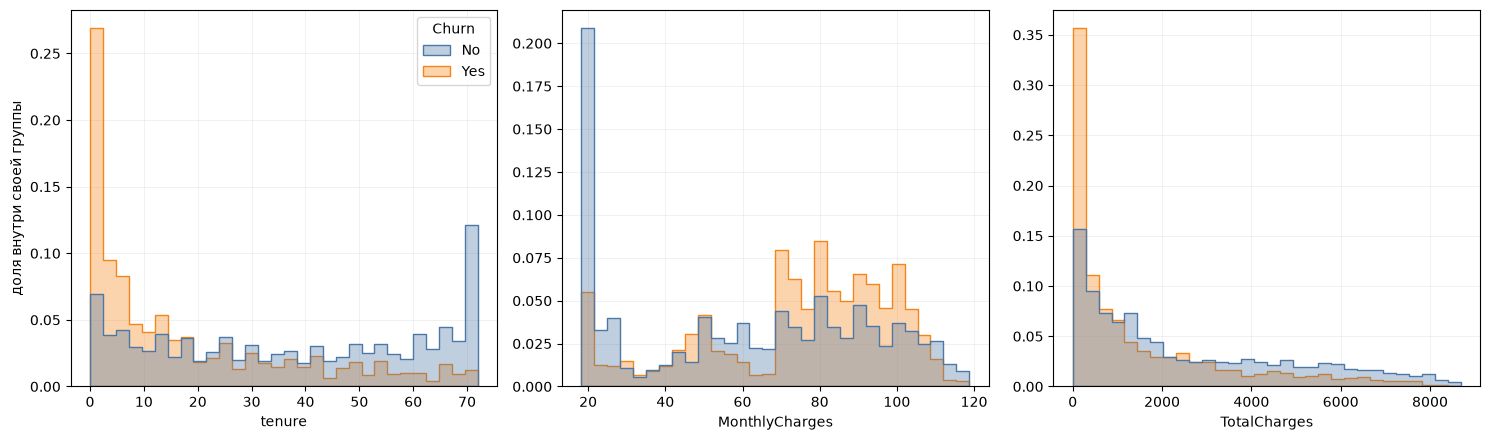

In [13]:
CHURN_COLORS = {"No": "#4c78a8", "Yes": "#f58518"}

plot_df = df.copy()
plot_df["TotalCharges"] = pd.to_numeric(plot_df["TotalCharges"], errors="coerce").fillna(0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for i, (ax, col) in enumerate(zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"])):
    # stat="probability" + common_norm=False: каждая группа нормируется на себя.
    # Без этого «остались» всегда выглядели бы выше просто потому, что их втрое больше,
    # и сравнить форму распределений было бы невозможно.
    sns.histplot(data=plot_df, x=col, hue="Churn", bins=30,
                 stat="probability", common_norm=False,
                 element="step", fill=True, alpha=0.35,
                 palette=CHURN_COLORS, legend=(i == 0), ax=ax)
    ax.set_ylabel("доля внутри своей группы" if i == 0 else "")
    ax.grid(alpha=0.25, linewidth=0.5)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

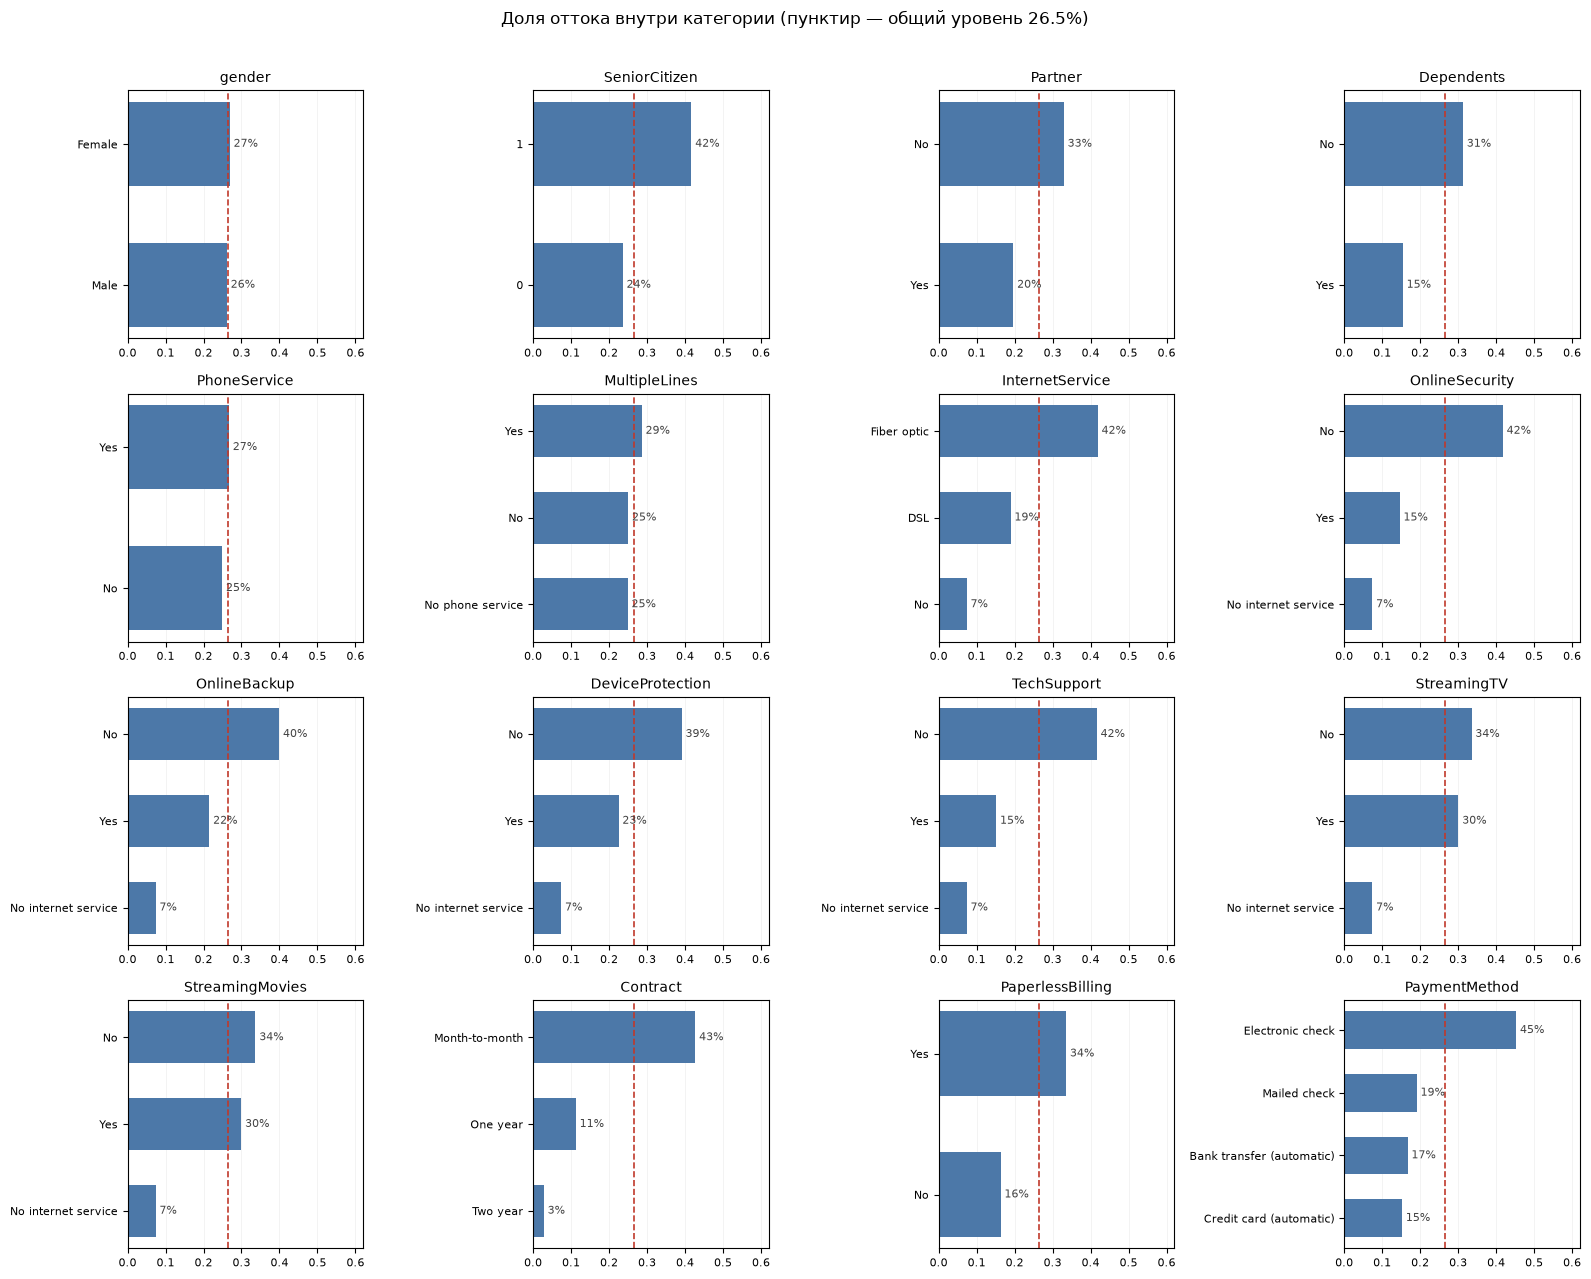

In [14]:
CAT_COLS = [c for c in df.columns
            if c not in ("customerID", "Churn", "tenure", "MonthlyCharges", "TotalCharges")]
overall = (df["Churn"] == "Yes").mean()

fig, axes = plt.subplots(4, 4, figsize=(16, 13))
for ax, col in zip(axes.ravel(), CAT_COLS):
    rate = (df.assign(y=(df["Churn"] == "Yes"))
              .groupby(col, observed=True)["y"].mean().sort_values())
    ax.barh([str(i) for i in rate.index], rate.values, color="#4c78a8", height=0.6)
    ax.axvline(overall, color="#c0392b", lw=1.2, ls="--")
    for y, v in enumerate(rate.values):
        ax.text(v + 0.01, y, f"{v:.0%}", va="center", fontsize=8, color="#444")
    ax.set_title(col, fontsize=10)
    ax.set_xlim(0, 0.62)
    ax.tick_params(labelsize=8)
    ax.grid(axis="x", alpha=0.2, linewidth=0.5)
    ax.set_axisbelow(True)

fig.suptitle(f"Доля оттока внутри категории (пунктир — общий уровень {overall:.1%})", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### Найденные несостыковки

Размер: **7043 строки × 21 колонка** (20 признаков + таргет `Churn`).

**1. `TotalCharges` имеет тип `str`, хотя это деньги.**
Причина — 11 значений, содержащих ровно один пробел (`' '`), а не число. Ключевое наблюдение: множество этих строк **полностью совпадает** с множеством строк, где `tenure == 0` (11 из 11, в обе стороны). То есть это клиенты, которые только что подключились и ещё ни разу не были выставлены к оплате: накопленной суммы у них ещё не существует. У всех 11 при этом заполнен `MonthlyCharges` и у всех `Churn == No`.

**2. Пропуски не видны стандартными средствами.**
`df.info()` показывает `7043 non-null` по всем колонкам, потому что `' '` — валидная строка, а не `NaN`. Проверка через `info()` или `isna()` на сырых данных здесь даёт ложноотрицательный ответ. Найти их удалось только через `pd.to_numeric(..., errors='coerce')`.

**3. `SeniorCitizen` закодирован не так, как его смысловые близнецы.**
Он `int64` со значениями `0/1`, тогда как все остальные бинарные признаки (`Partner`, `Dependents`, `PhoneService`, `PaperlessBilling`) — строки `Yes/No`. **Вывод: список категориальных признаков задаём явно, а не выводим из dtype.**

**4. `customerID` — технический идентификатор.**
7043 уникальных значения на 7043 строки. Предсказательной ценности нет, в признаки не идёт.

Важное следствие: проверять дубликаты через `df.duplicated()` **по всем колонкам бессмысленно** — при уникальном `customerID` ответ "дублей нет" получается по построению, независимо от содержимого данных. Проверять надо по набору признаков без идентификатора.

**5. `df.describe()` покрывает только 3 колонки из 21.**
По умолчанию берутся лишь числовые (`SeniorCitizen`, `tenure`, `MonthlyCharges`), причём статистики по `SeniorCitizen` бессмысленны (см. п. 3), а `TotalCharges` отсутствует из-за типа (см. п. 1). Для описания остальных 18 признаков нужен `describe(include='str')`.

**6. Дубликаты по признакам есть, и часть из них противоречива.**
Если убрать `customerID`, находится **33 группы строк-близнецов, охватывающие 73 строки** (1,04% данных). Из них **18 групп (42 строки) имеют одинаковые признаки, но разный `Churn`**.

**7. Третья категория в шести колонках услуг избыточна.**
`No internet service` встречается ровно тогда и только тогда, когда `InternetService == 'No'` — 1526 строк, маски совпадают полностью в обе стороны во всех шести колонках. Аналогично `No phone service` в `MultipleLines` <-> `PhoneService == 'No'` (682 строки). То есть факт "у клиента нет интернета" записан в данных семь раз.

Схлопывание `No internet service` -> `No` не должно приводить к потере информации, пока `InternetService` остается в признаках: различие между "нет услуги, потому что нет интернета" и "есть интернет, но услуга не подключена" сохраняется в `InternetService`. Делать это нужно одинаково для всех моделей — иначе XGBoost через one-hot и CatBoost с нативными категориями получат структурно разные данные, и сравнение библиотек перестанет быть честным.

**8. У всех категориальных признаков очень мало вариантов ответа.**
Самый "богатый" признак — `PaymentMethod` с 4 вариантами, у всех остальных 2 или 3. После схлопывания третьих категорий из п. 7 почти все станут бинарными.

**9. Классы несбалансированы: ушли 26,54% клиентов (1869 из 7043), соотношение 1 к 2,77.**
Перекос умеренный — не тот случай, когда редкий класс составляет доли процента. Но его достаточно, чтобы сделать accuracy негодной метрикой: модель, которая всегда отвечает "не уйдёт", не находит **ни одного** уходящего клиента и при этом имеет accuracy 0,7346. Любая осмысленная модель обязана превзойти это число, поэтому само по себе оно ничего не доказывает.

Что из этого следует:
- Основная метрика — **ROC-AUC**: она не зависит от порога и от пропорции классов, поэтому сравнима между моделями. Дополнительно смотрим **PR-AUC**, которая чувствительна именно к качеству на редком классе — а он нам и интересен, ведь бизнес хочет находить уходящих.
- Разбиение на фолды — **стратифицированное**, чтобы доля оттока в каждом фолде была одинаковой. Иначе часть разброса между фолдами будет объясняться не моделью, а случайным перекосом разбиения.
- Искусственная балансировка (SMOTE, undersampling) при соотношении 1 к 2,77 не нужна: она усложняет схему и мешает честному сравнению библиотек, почти ничего не давая взамен.

**10. `TotalCharges` — производный признак, а не самостоятельный.**
Корреляция `TotalCharges` с произведением `tenure × MonthlyCharges` равна **0,9996**, медиана их отношения — ровно 1,0, а 90% значений укладываются в коридор от 0,92 до 1,08. Отклонения объясняются тем, что тариф клиента за время обслуживания менялся. Фактически колонка вычисляется из двух других.

Два следствия:
- **Вопрос о заполнении 11 пропусков закрыт: ставим 0.** При `tenure == 0` формула даёт ровно ноль — это не эвристика, а то же правило, которому подчиняются остальные 7032 строки. Медиана подставила бы клиенту с нулевым сроком обслуживания сумму ≈1394 в прямом противоречии с этим правилом.
- **Важность признаков между библиотеками нельзя сравнивать напрямую.** Каждая из трёх по-своему поделит важность между `tenure`, `MonthlyCharges` и `TotalCharges`.

**11. Сигнал в данных есть, и он сосредоточен в нескольких признаках.**
Невозможных значений нет: `tenure` лежит в 0…72, `MonthlyCharges` в 18,25…118,75, отрицательных сумм не встречается.

Числовые признаки хорошо разделяют классы. Ушедшие резко смещены к малому `tenure` (27% из них — в первом месяце), тогда как у оставшихся заметный пик на 72 месяцах. По `MonthlyCharges` картина зеркальная: оставшиеся скучены на дешёвых тарифах около 20, ушедшие — в диапазоне 70…105. `TotalCharges` повторяет `tenure`, что ожидаемо после п. 10.

Разброс доли оттока по категориям (в процентных пунктах): `Contract` 39,9 (от 2,8% на двухлетнем контракте до 42,7% на помесячном — разница в 15 раз), `InternetService` 34,5, `PaymentMethod` 30,0. На другом конце — `gender` 0,8, `PhoneService` 1,8, `MultipleLines` 3,7: эти три признака отток практически не различают. Удалять их не нужно — деревья сами не станут по ним делить, — но и ожидать от них вклада не стоит.

Побочное подтверждение п. 7: у шести признаков услуг минимальная доля оттока совпадает с точностью до десятой (7,4%). Это категория `No internet service`, то есть одни и те же 1526 клиентов, посчитанные шесть раз.

Общий вывод: разделяющий сигнал в данных сильный, поэтому упереться модели должны примерно в один и тот же потолок.

#### Рабочая гипотеза (сформулирована до экспериментов)

Чтобы дерево могло работать с текстовой колонкой, её надо превратить в числа. Простейший способ — **one-hot**: колонку с N вариантами заменяют на N колонок из нулей и единиц, по одной на каждый вариант.

Слабое место one-hot — большое N. Именно на таких признаках и выигрывает CatBoost: он кодирует категорию **одним** числом — усреднённой долей оттока среди клиентов с этим значением, аккуратно посчитанной так, чтобы модель не подсмотрела правильный ответ.

Но у нас N равно 2, 3 или 4. One-hot добавит две-четыре колонки, ничего не потеряет и ничего не замедлит. То есть **на этих данных главное преимущество CatBoost просто не может проявиться**.

Отсюда предсказание, которое проверим цифрами: **XGBoost, LightGBM и CatBoost покажут практически одинаковое качество**. А различаться они будут не точностью, а скоростью обучения и тем, сколько ручной работы требуют на подготовку данных.

Следствие для методологии: сравнивать по среднему и разбросу (`mean ± std`) на фиксированных фолдах кросс-валидации и при равном бюджете подбора гиперпараметров. Сравнение по одному числу на одном разбиении на этих данных не докажет ничего.

#### Принятые решения

- **Заполнение 11 пропусков `TotalCharges`** — ставим 0 по формуле из п. 10.
- **Гипотеза `TotalCharges ≈ tenure × MonthlyCharges`** — подтверждена в Шаге 5, корреляция 0,9996.
- **Дубликаты** — убираем 22 точных повтора, противоречивые примеры сознательно сохраняем - объяснение будет дальше.

## Предобработка

Нумерация шагов здесь своя, независимая от нумерации в EDA.

### Шаг 1. Удаление точных повторов

Под "удалить дубликаты" скрываются две разные операции, и их важно не перепутать.

**Вариант А — убрать точные повторы**, у которых совпадают и все признаки, и ответ, оставив по одному представителю. Таких строк 22. Это законная дедупликация: одна и та же запись, попав одновременно в обучающую и тестовую выборку, позволяет модели буквально подсмотреть ответ и завышает оценку качества. **Делаем этот вариант.**

**Вариант Б — убрать все 42 строки из противоречивых групп**, где признаки совпадают, а `Churn` разный. От него отказываемся, и вот почему.

Такие строки не портят обучение. Если оба близнеца попали в train, модель выучивает для этого профиля вероятность около 0,5 — что и есть правильный ответ: клиенты с таким набором признаков действительно уходят примерно в половине случаев. Если близнецы разъехались между train и test, модель гарантированно ошибётся на тестовом, но это неустранимая ошибка, а не последствие "запутывания" модели.

Главное же в том, что доля оттока среди этих 42 строк — **47,6% против 26,5% в среднем по датасету**. Это самые пограничные и трудные клиенты. Удалив их, мы убрали бы из экзамена именно те вопросы, на которые невозможно ответить верно: метрики всех трёх библиотек выросли бы, но не потому, что модели стали лучше. Малый объём здесь не оправдание — удаляется не случайный процент данных, а систематически самая сложная их часть, поэтому смещение оценки идёт всегда в одну сторону.

Вдобавок эти строки — прямое свидетельство встроенного потолка качества из п. 6 выводов EDA, на котором держится вся наша методика сравнения. Удалить их значило бы разрушить основание собственного вывода.

In [15]:
# Дедуплицируем по признакам + таргету, но БЕЗ customerID: он уникален,
# и с ним ни одна пара строк никогда не совпадёт.
DEDUP_ON = [c for c in df.columns if c != "customerID"]

before = len(df)
data = df.drop_duplicates(subset=DEDUP_ON, keep="first").reset_index(drop=True)

print(f"было строк : {before}")
print(f"удалено    : {before - len(data)}")
print(f"осталось   : {len(data)}")

# Контроль: противоречивые строки должны остаться нетронутыми — мы их сознательно сохраняем.
X_COLS_CHK = [c for c in data.columns if c not in ("customerID", "Churn")]
g = data.groupby(X_COLS_CHK, dropna=False, observed=True)["Churn"].agg(n="size", uniq="nunique")
conf = g[g["uniq"] > 1]
print(f"\nпротиворечивых групп осталось: {len(conf)} | строк в них: {int(conf['n'].sum())}")
print(f"доля оттока изменилась       : {(df['Churn'] == 'Yes').mean():.4f} -> {(data['Churn'] == 'Yes').mean():.4f}")

было строк : 7043
удалено    : 22
осталось   : 7021

противоречивых групп осталось: 18 | строк в них: 36
доля оттока изменилась       : 0.2654 -> 0.2645


**Как читать вывод ячейки.** После дедупликации противоречивых групп по-прежнему 18, но строк в них 36, а не 42. Это не значит, что мы всё-таки задели противоречивые примеры. В группе вида `{Yes, Yes, No, No}` две пары были точными повторами, и вариант А схлопнул её до `{Yes, No}`: само противоречие уцелело, исчезло лишь дублирование внутри него. Общая доля оттока при этом сдвинулась с 0,2654 до 0,2645 — то есть практически не изменилась.

### Шаг 2. `TotalCharges` в число

Колонка хранится строкой из-за 11 значений `' '` (п. 1 выводов EDA). Приводим к числу, пропуски заполняем нулём.

Ноль здесь — не эвристика и не «разумное допущение». В Шаге 5 EDA мы установили, что `TotalCharges = tenure × MonthlyCharges` с корреляцией 0,9996, а у всех 11 строк `tenure == 0`. Значит формула даёт для них ровно ноль — то же правило, которому подчиняются остальные 7010 строк. Медиана или среднее подставили бы клиенту с нулевым сроком обслуживания сумму около 1394, прямо противоречащую этому правилу.

In [16]:
blank_before = pd.to_numeric(data["TotalCharges"], errors="coerce").isna().sum()
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce").fillna(0.0)

print(f"было нечисловых значений : {blank_before}")
print(f"стал тип                 : {data['TotalCharges'].dtype}")
print(f"осталось NaN             : {data['TotalCharges'].isna().sum()}")

# Контроль: нули должны стоять ровно у клиентов с нулевым сроком обслуживания.
zeros = data["TotalCharges"] == 0
print(f"\nнулей в TotalCharges     : {zeros.sum()}")
print(f"у всех ли из них tenure=0: {(data.loc[zeros, 'tenure'] == 0).all()}")

было нечисловых значений : 11
стал тип                 : float64
осталось NaN             : 0

нулей в TotalCharges     : 11
у всех ли из них tenure=0: True


### Шаг 3. Схлопывание избыточных категорий

В шести колонках интернет-услуг третье значение `No internet service` встречается ровно тогда, когда `InternetService == 'No'`, а `No phone service` в `MultipleLines` — ровно когда `PhoneService == 'No'` (п. 7 выводов EDA). Заменяем эти значения на обычное `No`.

Информация при этом не теряется: различие между «услуги нет, потому что нет интернета» и «интернет есть, но услуга не подключена» продолжает храниться в колонке `InternetService`, которую мы оставляем в признаках.

Зачем это нужно именно нам: без схлопывания XGBoost через one-hot получил бы семь колонок-копий признака `InternetService_No`, а CatBoost и LightGBM увидели бы трёхуровневую категорию и посчитали бы по третьему уровню отдельную статистику. Библиотеки учились бы на структурно разных данных, и сравнение перестало бы быть честным.

In [17]:
NET_SERVICES = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
                "TechSupport", "StreamingTV", "StreamingMovies"]

before = {c: data[c].nunique() for c in NET_SERVICES + ["MultipleLines"]}

for c in NET_SERVICES:
    data[c] = data[c].replace("No internet service", "No")
data["MultipleLines"] = data["MultipleLines"].replace("No phone service", "No")

for c in NET_SERVICES + ["MultipleLines"]:
    print(f"  {c:18} категорий: {before[c]} -> {data[c].nunique()}  {sorted(data[c].unique())}")

# Контроль: информация не потеряна — InternetService по-прежнему различает клиентов без интернета.
print(f"\nInternetService не тронут: {sorted(data['InternetService'].unique())}")
print(f"клиентов с InternetService == 'No': {(data['InternetService'] == 'No').sum()}")

  OnlineSecurity     категорий: 3 -> 2  ['No', 'Yes']
  OnlineBackup       категорий: 3 -> 2  ['No', 'Yes']
  DeviceProtection   категорий: 3 -> 2  ['No', 'Yes']
  TechSupport        категорий: 3 -> 2  ['No', 'Yes']
  StreamingTV        категорий: 3 -> 2  ['No', 'Yes']
  StreamingMovies    категорий: 3 -> 2  ['No', 'Yes']
  MultipleLines      категорий: 3 -> 2  ['No', 'Yes']

InternetService не тронут: ['DSL', 'Fiber optic', 'No']
клиентов с InternetService == 'No': 1512


### Шаг 4. `SeniorCitizen` к общему виду

Признак хранится как `int64` со значениями `0/1`, тогда как все остальные бинарные признаки того же смысла — строки `Yes/No` (п. 3 выводов EDA). Приводим к общему виду.

На качество это не влияет: для бинарного признака числовое разбиение по `≤ 0,5` и категориальное дают одно и то же дерево. Смысл в другом — убрать ловушку. Если позже определять список категориальных признаков автоматически через `select_dtypes`, `SeniorCitizen` уехал бы в числовые, а `Partner` и `Dependents` — в категориальные, и одинаковые по природе признаки достались бы библиотекам в разном виде.

In [18]:
print(f"было : {data['SeniorCitizen'].dtype}, значения {sorted(data['SeniorCitizen'].unique())}")

data["SeniorCitizen"] = data["SeniorCitizen"].map({0: "No", 1: "Yes"})

print(f"стало: {data['SeniorCitizen'].dtype}, значения {sorted(data['SeniorCitizen'].unique())}")
print(f"\nдоля пенсионеров не изменилась: {(data['SeniorCitizen'] == 'Yes').mean():.4f}")

было : int64, значения [np.int64(0), np.int64(1)]
стало: str, значения ['No', 'Yes']

доля пенсионеров не изменилась: 0.1625


### Шаг 5. Новые признаки

**Добавляем два признака**, оба выведены из находок EDA.

`ChargesRatio` = `TotalCharges / (tenure × MonthlyCharges)`. В Шаге 5 EDA мы выяснили, что это отношение имеет медиану ровно 1,0, а 90% значений лежат в коридоре 0,92…1,08. Отклонение от единицы означает, что тариф клиента за время обслуживания менялся: значение меньше 1 — сейчас платит больше, чем платил в среднем раньше, больше 1 — наоборот. В явном виде такой информации в данных нет, а для оттока история подорожания выглядит осмысленной. Клиентам с `tenure == 0` ставим 1,0: истории у них ещё нет, нейтральное значение честнее любого другого.

`NumServices` — сколько всего услуг подключено, из восьми возможных. Дерево способно собрать такой счётчик само, но только длинной цепочкой разбиений; поданный готовым, он экономит модели глубину.

**Про удаление признаков.** Кандидат один — `gender`: доля оттока среди женщин 26,9%, среди мужчин 26,2%, разброс 0,8 процентного пункта при общем уровне 26,5% (п. 11 выводов EDA). Но удалять его здесь мы не будем: решение по цифрам EDA — это догадка, а не замер. Признак остаётся в `data`, в матрицу `X` не включается, и его нужность проверяется отдельным экспериментом в разделе "Дополнительные проверки".

**А `PhoneService` убирать нельзя**, хотя по разбросу он тоже слабый (1,8 п.п.). Причина — в Шаге 3 мы схлопнули `No phone service` → `No` в колонке `MultipleLines`. После этого значение `No` там означает сразу две разные вещи: "телефон есть, линия одна" и "телефона нет вовсе". Различить их теперь может только `PhoneService`. Убрав его, мы потеряли бы информацию, которую сами же туда переложили.

Это ровно та же логика, по которой мы сохранили `InternetService`: колонка, принимающая на себя смысл после схлопывания, становится обязательной.

In [19]:
SERVICE_COLS = ["PhoneService", "MultipleLines", "OnlineSecurity", "OnlineBackup",
                "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]

# Отношение фактической суммы к «ожидаемой» tenure * MonthlyCharges.
# Отклонение от 1.0 = тариф менялся. При tenure == 0 знаменатель нулевой,
# истории нет — ставим нейтральную единицу.
expected = data["tenure"] * data["MonthlyCharges"]
data["ChargesRatio"] = (data["TotalCharges"] / expected.where(expected != 0)).fillna(1.0)

data["NumServices"] = (data[SERVICE_COLS] == "Yes").sum(axis=1)

print("ChargesRatio:")
print(data["ChargesRatio"].describe(percentiles=[.05, .5, .95]).round(4).to_string())
print(f"\nNumServices: {data['NumServices'].min()}…{data['NumServices'].max()}, "
      f"медиана {data['NumServices'].median():.0f}")
print(data["NumServices"].value_counts().sort_index().to_string())
print(f"\nколонок в data: {data.shape[1]}")

ChargesRatio:
count    7021.0000
mean        1.0003
std         0.0512
min         0.6894
5%          0.9244
50%         1.0000
95%         1.0749
max         1.5735

NumServices: 0…8, медиана 3
NumServices
0      80
1    1679
2    1188
3     965
4     922
5     908
6     676
7     395
8     208

колонок в data: 23


### Шаг 6. Матрица признаков и таргет

Финальная сборка: убираем `customerID` (7043 уникальных значения на 7043 строки — чистый идентификатор), переводим `Churn` в 0/1 и раскладываем колонки по двум явным спискам.

**Списки признаков задаются руками, а не через `select_dtypes`** — это принципиально. Автоматическое определение по типу данных привязало бы состав признаков к тому, как они случайно оказались закодированы в исходном CSV. Явные списки гарантируют, что XGBoost, LightGBM и CatBoost получат ровно одни и те же признаки в ровно тех же ролях, а значит сравнение будет измерять разницу между библиотеками, а не разницу в подготовке данных.

`NumServices` относим к числовым: это счётчик от 0 до 8, у которого порядок осмыслен, — "пять услуг" действительно больше "двух".

Проверка полноты в конце ячейки (`assert`) страхует от тихой потери колонки: сумма числовых, категориальных, таргета и идентификатора обязана совпасть с фактическим набором колонок.

In [20]:
TARGET = "Churn"
ID_COL = "customerID"

NUM_FEATURES = ["tenure", "MonthlyCharges", "TotalCharges", "ChargesRatio", "NumServices"]

CAT_FEATURES = [
    "SeniorCitizen", "Partner", "Dependents",
    "PhoneService", "MultipleLines", "InternetService",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod",
]

# Признаки, исключённые из X, но оставленные в data: их нужность проверяется
# экспериментом в разделе «Дополнительные проверки», а не решается рассуждением.
EXCLUDED = ["gender"]

X = data[NUM_FEATURES + CAT_FEATURES].copy()
y = (data[TARGET] == "Yes").astype(int)

# Ни одна колонка не должна потеряться незаметно.
assert (set(NUM_FEATURES) | set(CAT_FEATURES) | set(EXCLUDED) | {TARGET, ID_COL}
        == set(data.columns))
assert X.isna().sum().sum() == 0, "в матрице признаков остались пропуски"

print(f"X: {X.shape[0]} строк, {X.shape[1]} признаков "
      f"({len(NUM_FEATURES)} числовых + {len(CAT_FEATURES)} категориальных)")
print(f"исключены из X, но сохранены в data: {EXCLUDED}")
print(f"y: доля класса 1 (ушёл) = {y.mean():.4f}")
print(f"\nкатегорий на признак: {sorted(X[CAT_FEATURES].nunique().unique())} "
      f"(максимум {X[CAT_FEATURES].nunique().max()})")

X: 7021 строк, 20 признаков (5 числовых + 15 категориальных)
исключены из X, но сохранены в data: ['gender']
y: доля класса 1 (ушёл) = 0.2645

категорий на признак: [np.int64(2), np.int64(3), np.int64(4)] (максимум 4)


### Шаг 7. Кодирование категорий через `LabelEncoder`

Деревья работают с числами, поэтому 15 категориальных колонок надо перевести в целые метки.

**`LabelEncoder` формально предназначен для таргета, а не для признаков.** Он рассчитан на одномерный массив, и для матрицы признаков в sklearn есть `OrdinalEncoder`. Применение по колонке за раз работает корректно и в задании указано использовать его, поэтому так и делаем.

**Кодирование навязывает порядок, которого нет.** Метки присваиваются по алфавиту, так что `PaymentMethod` превращается в последовательность "банковский перевод / карта / электронный чек / почтовый чек", где "больше" и "меньше" бессмысленны. Для линейной модели это была бы грубая ошибка. Для деревьев — терпимо: дерево может выделить любую отдельную категорию несколькими последовательными разбиениями, а при 2–4 категориях таких разбиений нужно совсем немного. С `Contract` вообще повезло: алфавитный порядок `Month-to-month → One year → Two year` случайно совпал с осмысленным.

И главное для нашей задачи: целочисленные метки — это **штатный входной формат**. То есть после кодирования все три библиотеки получат буквально одинаковую матрицу, а дальше каждая обработает категории своим механизмом. Именно этого мы и добивались: сравнение измерит разницу между алгоритмами, а не между способами подготовки данных.

Кодируем **до** разбиения на train и test. Здесь это безопасно: `LabelEncoder` строит словарь по названиям категорий и не смотрит на таргет, так что подсмотреть ответ через него невозможно. Побочная выгода — в тесте гарантированно не встретится категория, которой не было при обучении кодировщика.

In [21]:
from sklearn.preprocessing import LabelEncoder

# Кодировщики сохраняем: без них нельзя будет расшифровать метки
# при разборе важности признаков и деревьев.
encoders = {}
for col in CAT_FEATURES:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

print("соответствие меток (первые три признака и два самых важных по EDA):")
for col in ["SeniorCitizen", "Partner", "Dependents", "Contract", "PaymentMethod"]:
    mapping = {cls: i for i, cls in enumerate(encoders[col].classes_)}
    print(f"  {col:16} {mapping}")

print(f"\nвсе колонки числовые: {X.dtypes.map(pd.api.types.is_numeric_dtype).all()}")
print(f"типы: {X.dtypes.value_counts().to_dict()}")
print(f"пропусков: {X.isna().sum().sum()}")

соответствие меток (первые три признака и два самых важных по EDA):
  SeniorCitizen    {'No': 0, 'Yes': 1}
  Partner          {'No': 0, 'Yes': 1}
  Dependents       {'No': 0, 'Yes': 1}
  Contract         {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
  PaymentMethod    {'Bank transfer (automatic)': 0, 'Credit card (automatic)': 1, 'Electronic check': 2, 'Mailed check': 3}

все колонки числовые: True
типы: {dtype('int64'): 17, dtype('float64'): 3}
пропусков: 0


### Чего сознательно не делаем и почему

В стандартном пайплайне предобработки есть несколько шагов, которых здесь нет. Это не упущение: все они бессмысленны для градиентного бустинга, и у всех один общий корень — **дерево делит выборку по правилу "признак больше или меньше порога", то есть использует только порядок значений, а не их величину**. Любое монотонное преобразование признака оставляет все разбиения на своих местах.

**1. Не ищем и не удаляем выбросы.** Клиент с `TotalCharges = 8684` попадёт в крайний лист ровно так же, как попал бы при значении 8 684 000. Настоящих выбросов в данных и нет: максимум — это законные 72 месяца по дорогому тарифу, и удалять такого клиента значило бы выбросить самого ценного. Проверяли мы другое — невозможные значения (отрицательные суммы, срок больше 72 месяцев), и их не нашлось.

**2. Не боремся с коррелированными признаками.** Многоколлинеарность ломает линейную регрессию: та решает систему уравнений и не может распределить эффект между почти одинаковыми признаками, из-за чего коэффициенты становятся неустойчивыми. Дерево коэффициентов не оценивает — оно просто выбирает, по какому признаку выгоднее разбить. Поэтому мы не только оставили `TotalCharges` при корреляции 0,9996 с произведением `tenure × MonthlyCharges`, но и добавили `ChargesRatio`, выведенный из той же тройки. Цена — только в интерпретации важности признаков (п. 10 выводов EDA).

**3. Не масштабируем и не логарифмируем.** Ни `StandardScaler`, ни `MinMaxScaler` не применяем, хотя `tenure` лежит в 0…72, а `TotalCharges` — в 0…8684. Для линейных моделей, SVM и kNN такая разница масштабов критична, потому что они считают расстояния или взвешенные суммы. Порог `tenure ≤ 12` дерево находит независимо от того, в каких единицах измеряется соседняя колонка. Логарифмирование скошенного `TotalCharges` — из той же серии: монотонное преобразование, ни одного разбиения не изменит.

**Где граница этого рассуждения.** Инвариантность относится к признакам, а не ко всему остальному:

- В **регрессии** с квадратичной ошибкой выброс в целевой переменной даёт огромный градиент и реально портит обучение. У нас таргет бинарный, поэтому неактуально.
- Шум в **разметке** бустинг не прощает: 42 строки с одинаковыми признаками и разным ответом (п. 6 выводов EDA) задают потолок достижимого качества, и никакая инвариантность здесь не спасает.
- Признаки мы всё-таки трогали, но по другим причинам: схлопывали избыточные категории, чтобы все три библиотеки получили одинаковые данные, и кодировали текст в числа, потому что иначе деревья с ним просто не работают.

## Схема эксперимента

Нумерация шагов снова своя.

Прежде чем обучать модели, фиксируем правила игры. Главный риск этой работы — получить красивые числа, которые ничего не доказывают: на данных с встроенным потолком качества (п. 6 выводов EDA) разница между библиотеками заведомо мала, и её легко спутать со случайностью.

**Правила сравнения.**

1. **Отложенная тестовая выборка — 20%, стратифицированная.** Не трогаем её до самого конца: она нужна для финальной непредвзятой оценки, после того как все гиперпараметры уже подобраны.
2. **Одни и те же фолды для всех библиотек.** Объекты кросс-валидации создаются один раз с фиксированным `random_state`. Если каждая модель получит своё разбиение, часть разницы между ними будет объясняться разбиением, а не самой моделью.
3. **Отчитываемся средним и разбросом (`mean ± std`), а не одним числом.** Если разрыв между библиотеками меньше разброса между фолдами — честный вывод «различий не обнаружено», а не «победил такой-то».
4. **Повторная кросс-валидация для итогового сравнения** — 5 фолдов × 3 повтора. Пятнадцать оценок вместо пяти дают куда более надёжную оценку разброса, а он нам здесь важнее среднего. Для подбора гиперпараметров используем обычные 5 фолдов, чтобы не утроить стоимость перебора.
5. **Равный бюджет подбора гиперпараметров** — одинаковое число попыток на каждую библиотеку. Иначе сравнение превратится в соревнование «кому больше досталось вычислений».
6. **Основная метрика — ROC-AUC**, дополнительная — PR-AUC (обоснование в п. 9 выводов EDA). Accuracy не используем: константный ответ «не уйдёт» даёт 0,7346 и создаёт иллюзию хорошего результата.

**Запланированный отдельный эксперимент.** Проверить, нужен ли признак `TotalCharges`. Он почти полностью выражается через `tenure × MonthlyCharges` (корреляция 0,9996, п. 10 выводов EDA), но при этом даёт деревьям готовое произведение, которое иначе пришлось бы приближать лесенкой из разбиений. Прогоняем сравнение дважды — с ним и без него — и смотрим, превышает ли разница разброс между фолдами. Ответ «признак не влияет», подкреплённый цифрами, ценнее любого рассуждения.

### Шаг 1. Отложенная выборка и фиксированные фолды

In [22]:
from sklearn.model_selection import (
    StratifiedKFold, RepeatedStratifiedKFold, train_test_split,
)

RANDOM_STATE = 42
TEST_SIZE = 0.2

# stratify=y обязателен: при доле оттока 26% случайное разбиение заметно
# разошлось бы по классам, и test отвечал бы на слегка другой вопрос, чем train.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE,
)

# Фолды создаются один раз и переиспользуются всеми библиотеками:
# так разница в метриках не сможет объясняться разным разбиением.
cv_tune = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_eval = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)

print(f"исходно : {len(X):5d} строк | доля оттока {y.mean():.4f}")
print(f"train   : {len(X_train):5d} строк | доля оттока {y_train.mean():.4f}")
print(f"test    : {len(X_test):5d} строк | доля оттока {y_test.mean():.4f}")

print(f"\nfolds на подбор гиперпараметров: {cv_tune.get_n_splits()}")
print(f"folds на итоговую оценку       : {cv_eval.get_n_splits()} (5 фолдов x 3 повтора)")

# Контроль стратификации: доля оттока в каждом валидационном фолде должна быть одинаковой.
rates = [y_train.iloc[va].mean() for _, va in cv_tune.split(X_train, y_train)]
print(f"\nдоля оттока по фолдам: {[f'{r:.4f}' for r in rates]}")
print(f"разброс между фолдами: {max(rates) - min(rates):.4f}")

исходно :  7021 строк | доля оттока 0.2645
train   :  5616 строк | доля оттока 0.2644
test    :  1405 строк | доля оттока 0.2648

folds на подбор гиперпараметров: 5
folds на итоговую оценку       : 15 (5 фолдов x 3 повтора)

доля оттока по фолдам: ['0.2642', '0.2645', '0.2645', '0.2645', '0.2645']
разброс между фолдами: 0.0002


## Бустинг "из коробки"

Нумерация шагов своя.

### Шаг 1. Четыре реализации с параметрами по умолчанию

Обучаем четыре модели без настройки гиперпараметров: `GradientBoostingClassifier` из sklearn, XGBoost, LightGBM, CatBoost. Матрица признаков и 15 фолдов (5 разбиений × 3 повтора) у всех одинаковые.

Что задаём вручную:

- `random_state` — для воспроизводимости, на качество не влияет;
- `verbose=-1` у LightGBM и `verbose=0` у CatBoost — глушат журнал обучения.

**Категориальные признаки не объявляем.** У CatBoost есть `cat_features`, у LightGBM — `categorical_feature`. Если включить их сейчас, две библиотеки будут обрабатывать данные иначе, чем остальные две, и сравнение перестанет измерять алгоритмы. Пока все четыре видят целые метки как обычные числа. Нативную обработку категорий проверим отдельно.

`n_jobs=1` — фолды считаем последовательно, иначе замеры времени обучения будут искажены: модели сами занимают все ядра.

In [23]:
from time import perf_counter

from sklearn.model_selection import cross_validate
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

SCORING = {"roc_auc": "roc_auc", "pr_auc": "average_precision"}

MODELS = {
    "sklearn GB": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "XGBoost":    XGBClassifier(random_state=RANDOM_STATE),
    "LightGBM":   LGBMClassifier(random_state=RANDOM_STATE, verbose=-1),
    "CatBoost":   CatBoostClassifier(random_state=RANDOM_STATE, verbose=0),
}

fold_scores = {}   # оценки по каждому фолду — понадобятся для парного сравнения в Шаге 2
rows = []

for name, model in MODELS.items():
    t0 = perf_counter()
    cv_res = cross_validate(model, X_train, y_train, cv=cv_eval, scoring=SCORING, n_jobs=1)
    elapsed = perf_counter() - t0

    fold_scores[name] = cv_res["test_roc_auc"]
    rows.append({
        "модель":  name,
        "ROC-AUC": cv_res["test_roc_auc"].mean(),
        "std":     cv_res["test_roc_auc"].std(),
        "PR-AUC":  cv_res["test_pr_auc"].mean(),
        "std ":    cv_res["test_pr_auc"].std(),
        "fit, с":  cv_res["fit_time"].mean(),
    })
    print(f"{name:11} посчитан за {elapsed:5.1f} c")

baseline = pd.DataFrame(rows).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
print()
print(baseline.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

sklearn GB  посчитан за   5.7 c


XGBoost     посчитан за   2.0 c


LightGBM    посчитан за   6.7 c


CatBoost    посчитан за  19.3 c

    модель  ROC-AUC    std  PR-AUC   std   fit, с
sklearn GB   0.8445 0.0133  0.6550 0.0240  0.3741
  CatBoost   0.8400 0.0140  0.6469 0.0285  1.2836
  LightGBM   0.8317 0.0149  0.6283 0.0305  0.4398
   XGBoost   0.8178 0.0155  0.6018 0.0315  0.1289


### Шаг 2. Парное сравнение на одинаковых фолдах

Разрыв между первым и последним местом — около 0,027. Разброс каждой модели по фолдам — около 0,014. Сравнивать эти два числа напрямую нельзя.

Разброс 0,014 — это в основном разброс самих фолдов: одни разбиения труднее других, и на трудном фолде просядут все модели сразу. К разнице между моделями это отношения не имеет.

Все четыре модели считались на одних и тех же фолдах, поэтому нужен парный тест: считаем разность метрик внутри каждого фолда. Общая трудность фолда при вычитании сокращается.

Ещё смотрим, в скольких фолдах из 15 победил лидер. Если почти во всех — разница устойчивая, а не результат пары удачных разбиений.

In [24]:
from scipy import stats

LEADER = baseline.loc[0, "модель"]
base = fold_scores[LEADER]

print(f"Лидер: {LEADER}. Разности ROC-AUC внутри каждого из 15 фолдов:\n")
print(f"{'соперник':11} {'разница':>9} {'std разн.':>10} {'p-value':>9} {'побед':>7}  вывод")

for name in baseline["модель"][1:]:
    diff = base - fold_scores[name]
    _, p = stats.ttest_rel(base, fold_scores[name])
    wins = int((diff > 0).sum())
    verdict = "различие значимо" if p < 0.05 else "различие не доказано"
    print(f"{name:11} {diff.mean():+9.4f} {diff.std():10.4f} {p:9.1e} {wins:5d}/15  {verdict}")

print("\nДля контраста — разброс каждой модели по фолдам (общая трудность фолдов):")
for name, scores in fold_scores.items():
    print(f"  {name:11} std = {scores.std():.4f}")

Лидер: sklearn GB. Разности ROC-AUC внутри каждого из 15 фолдов:

соперник      разница  std разн.   p-value   побед  вывод
CatBoost      +0.0044     0.0030   8.2e-05    14/15  различие значимо
LightGBM      +0.0127     0.0037   3.6e-09    15/15  различие значимо
XGBoost       +0.0266     0.0057   6.2e-11    15/15  различие значимо

Для контраста — разброс каждой модели по фолдам (общая трудность фолдов):
  sklearn GB  std = 0.0133
  XGBoost     std = 0.0155
  LightGBM    std = 0.0149
  CatBoost    std = 0.0140


### Шаг 3. Откуда взялся такой порядок

Победила самая старая реализация — `GradientBoostingClassifier` из sklearn. XGBoost на последнем месте, отставание 0,027. Все различия значимы, sklearn обошёл XGBoost в 15 фолдах из 15.

Но вывод «sklearn лучше XGBoost» делать нельзя. Надо понять, что мы измерили. Ячейка ниже выводит фактические параметры по умолчанию.

In [25]:
import json

# У XGBoost sklearn-обёртка хранит None вместо дефолтов: настоящие значения
# лежат в C++ ядре, поэтому достаём их из конфига обученного бустера.
xgb_cfg = json.loads(
    XGBClassifier().fit([[0], [1]], [0, 1]).get_booster().save_config()
)["learner"]["gradient_booster"]["tree_train_param"]

gb = GradientBoostingClassifier().get_params()
lgb = LGBMClassifier().get_params()

print(f"{'библиотека':11} {'деревьев':>9} {'learning_rate':>14} {'глубина':>9}")
print(f"{'sklearn GB':11} {gb['n_estimators']:9d} {gb['learning_rate']:14.2f} {gb['max_depth']:9d}")
print(f"{'XGBoost':11} {100:9d} {float(xgb_cfg['eta']):14.2f} {int(xgb_cfg['max_depth']):9d}")
print(f"{'LightGBM':11} {lgb['n_estimators']:9d} {lgb['learning_rate']:14.2f} "
      f"{'~5':>9}   (num_leaves={lgb['num_leaves']})")
print(f"{'CatBoost':11} {1000:9d} {'авто ~0.03':>14} {6:9d}")

библиотека   деревьев  learning_rate   глубина
sklearn GB        100           0.10         3
XGBoost           100           0.30         6
LightGBM          100           0.10        ~5   (num_leaves=31)
CatBoost         1000     авто ~0.03         6


Причина в разных настройках по умолчанию:

- **XGBoost** — шаг 0,3, глубина 6. Большой шаг и глубокие деревья. На 5616 строках с шумной разметкой это ведёт к переобучению.
- **sklearn GB** — шаг 0,1, глубина 3. Мелкий шаг и мелкие деревья, то есть регуляризация уже заложена в дефолты.
- **CatBoost** — 1000 деревьев вместо 100, шаг около 0,03. Много слабых итераций.
- **LightGBM** — шаг 0,1, `num_leaves = 31`, это примерно глубина 5. Посередине.

Порядок в таблице совпадает с тем, насколько консервативны настройки. То есть на этом этапе мы сравнили не алгоритмы, а их значения по умолчанию. XGBoost проиграл не потому, что хуже: его дефолты рассчитаны на большие данные, где шаг 0,3 и глубина 6 оправданы.

Гипотезу про равенство библиотек проверим на следующем этапе, когда все четыре получат одинаковый бюджет подбора параметров.

### Шаг 4. Проверка на отложенной выборке

Обучаем каждую модель на всём train (5616 строк) и считаем метрики на отложенных 1405 строках, которые до этого не использовались.

Заодно сравниваем результат на тесте с результатом кросс-валидации. Если тест окажется заметно хуже, значит мы подогнались под фолды.

In [26]:
from sklearn.metrics import roc_auc_score, average_precision_score

test_preds = {}   # вероятности на тесте — понадобятся для бутстрэпа в Шаге 5
rows = []

for name, model in MODELS.items():
    t0 = perf_counter()
    model.fit(X_train, y_train)
    fit_time = perf_counter() - t0

    proba = model.predict_proba(X_test)[:, 1]
    test_preds[name] = proba

    cv_mean = baseline.loc[baseline["модель"] == name, "ROC-AUC"].iloc[0]
    test_auc = roc_auc_score(y_test, proba)

    rows.append({
        "модель":       name,
        "CV ROC-AUC":   cv_mean,
        "TEST ROC-AUC": test_auc,
        "test - CV":    test_auc - cv_mean,
        "TEST PR-AUC":  average_precision_score(y_test, proba),
        "fit, с":       fit_time,
    })

holdout = pd.DataFrame(rows).sort_values("TEST ROC-AUC", ascending=False).reset_index(drop=True)
print(holdout.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print(f"\ntest: {len(y_test)} строк, доля оттока {y_test.mean():.4f}")

    модель  CV ROC-AUC  TEST ROC-AUC  test - CV  TEST PR-AUC  fit, с
  CatBoost      0.8400        0.8374    -0.0027       0.6356  1.3913
sklearn GB      0.8445        0.8372    -0.0072       0.6467  0.4875
  LightGBM      0.8317        0.8318     0.0000       0.6179  0.4256
   XGBoost      0.8178        0.8137    -0.0042       0.5986  0.1457

test: 1405 строк, доля оттока 0.2648


### Шаг 5. Насколько можно верить порядку на тесте

На тесте лидер поменялся: первым стал CatBoost, а на кросс-валидации первым был sklearn GB. Отрыв при этом 0,0002 — то есть его фактически нет.

Тест — это одна выборка из 1405 строк, в ней всего 372 ушедших клиента. Метрика на такой выборке сама по себе случайна: попались бы другие 1405 клиентов — получились бы другие числа. Объявлять победителя по разнице в 0,0002 нельзя.

Чтобы понять масштаб этой случайности, используем **бутстрэп**: много раз берём из теста выборку того же размера с возвращением и каждый раз считаем ROC-AUC. Разброс полученных значений и показывает, насколько метрика неустойчива.

Для сравнения моделей считаем разность внутри каждого пересэмплирования — так же, как в парном тесте на фолдах. Если 95% интервал разности накрывает ноль, разница не доказана.

In [27]:
N_BOOT = 2000
rng = np.random.default_rng(RANDOM_STATE)
y_test_arr = y_test.to_numpy()

# Пересэмплирования делаем один раз и переиспользуем для всех моделей:
# иначе разность считалась бы на разных выборках и стала бы бессмысленной.
boot_idx = [rng.choice(len(y_test_arr), len(y_test_arr), replace=True) for _ in range(N_BOOT)]
boot_idx = [i for i in boot_idx if y_test_arr[i].std() > 0]   # отбрасываем выборки одного класса

boot_auc = {
    name: np.array([roc_auc_score(y_test_arr[i], proba[i]) for i in boot_idx])
    for name, proba in test_preds.items()
}

print(f"Бутстрэп теста, {len(boot_idx)} пересэмплирований. 95% интервал ROC-AUC:\n")
for name in holdout["модель"]:
    b = boot_auc[name]
    lo, hi = np.percentile(b, [2.5, 97.5])
    print(f"  {name:11} {roc_auc_score(y_test_arr, test_preds[name]):.4f}  "
          f"[{lo:.4f}, {hi:.4f}]  ширина {hi - lo:.4f}")

print("\nПарные разности (внутри каждого пересэмплирования):\n")
names = list(holdout["модель"])
for i, a in enumerate(names):
    for b_name in names[i + 1:]:
        d = boot_auc[a] - boot_auc[b_name]
        lo, hi = np.percentile(d, [2.5, 97.5])
        verdict = "значимо" if lo > 0 or hi < 0 else "НЕ значимо"
        print(f"  {a:11} - {b_name:11} {d.mean():+.4f}  [{lo:+.4f}, {hi:+.4f}]  {verdict}")

Бутстрэп теста, 2000 пересэмплирований. 95% интервал ROC-AUC:

  CatBoost    0.8374  [0.8162, 0.8588]  ширина 0.0426
  sklearn GB  0.8372  [0.8150, 0.8598]  ширина 0.0447
  LightGBM    0.8318  [0.8104, 0.8542]  ширина 0.0438
  XGBoost     0.8137  [0.7899, 0.8373]  ширина 0.0473

Парные разности (внутри каждого пересэмплирования):

  CatBoost    - sklearn GB  +0.0001  [-0.0069, +0.0070]  НЕ значимо
  CatBoost    - LightGBM    +0.0055  [-0.0016, +0.0126]  НЕ значимо
  CatBoost    - XGBoost     +0.0237  [+0.0124, +0.0350]  значимо
  sklearn GB  - LightGBM    +0.0054  [-0.0031, +0.0141]  НЕ значимо
  sklearn GB  - XGBoost     +0.0236  [+0.0103, +0.0365]  значимо
  LightGBM    - XGBoost     +0.0182  [+0.0080, +0.0287]  значимо


### Итоги этапа

**Переобучение.** Разница между тестом и кросс-валидацией: от 0,000 до 0,007. Подгонки под фолды нет.

**Кросс-валидация, 15 фолдов, парный t-тест.** Порядок: sklearn GB 0,8445 → CatBoost 0,8400 → LightGBM 0,8317 → XGBoost 0,8178. Все различия с лидером значимы, p от 8,2e-05 до 6,2e-11. Побед лидера: 14 из 15 над CatBoost, 15 из 15 над LightGBM и XGBoost.

**Отложенная выборка, 1405 строк, бутстрэп 2000 пересэмплирований.** Порядок: CatBoost 0,8374 → sklearn GB 0,8372 → LightGBM 0,8318 → XGBoost 0,8137. Значимо отстаёт только XGBoost. Интервалы разностей между CatBoost, sklearn GB и LightGBM накрывают ноль.

**Разрешающая способность двух методов различается.** Ширина 95% интервала ROC-AUC на тесте — 0,043, точность отдельного значения около ±0,02. Кросс-валидация считает разность 15 раз на общих фолдах, вклад трудности фолда при вычитании сокращается. Порядок моделей определяется по кросс-валидации, тест служит проверкой на переобучение.

**Лидер по кросс-валидации — sklearn GB**, отставание CatBoost 0,0044. На тесте эти две модели меняются местами, разрыв 0,0002, то есть на два порядка меньше погрешности теста.

**XGBoost последний в обоих измерениях.**

**Связь с настройками по умолчанию.** Порядок моделей совпадает с порядком консервативности дефолтов: sklearn GB — шаг 0,1 и глубина 3, LightGBM — шаг 0,1 и 31 лист, CatBoost — 1000 деревьев шагом 0,03, XGBoost — шаг 0,3 и глубина 6.

**Статус рабочей гипотезы.** Не подтверждена: различия между библиотеками значимы. Фактор разных дефолтов не устранён, поэтому результат характеризует настройки, а не алгоритмы. Проверка гипотезы переносится на этап подбора гиперпараметров с равным бюджетом.

## Подбор гиперпараметров

Нумерация шагов своя.

Настраиваем основные параметры: скорость обучения, глубину деревьев, число деревьев, долю объектов (`subsample`) и долю признаков (`max_features` и его аналоги).

**Названия параметров у библиотек разные**, поэтому вводим логические имена и переводим их в фактические:

| логическое имя | sklearn GB | XGBoost | LightGBM | CatBoost |
|---|---|---|---|---|
| `learning_rate` | `learning_rate` | `learning_rate` | `learning_rate` | `learning_rate` |
| `depth` | `max_depth` | `max_depth` | `max_depth` + `num_leaves` | `depth` |
| `n_trees` | `n_estimators` | `n_estimators` | `n_estimators` | `iterations` |
| `subsample` | `subsample` | `subsample` | `subsample` + `subsample_freq` | `subsample` + `bootstrap_type` |
| `feat_frac` | `max_features` | `colsample_bytree` | `colsample_bytree` | `rsm` |

Три случая требуют дополнительных параметров, иначе основной молча игнорируется:

- **LightGBM, глубина.** По умолчанию `num_leaves = 31`, что соответствует глубине около 5. Если задать только `max_depth`, при малых значениях ограничение придёт от глубины, а при больших — от числа листьев. Поэтому задаём и `num_leaves = 2^depth`.
- **LightGBM, `subsample`.** Работает только при `subsample_freq >= 1`. По умолчанию 0, то есть подвыборка выключена и параметр не влияет ни на что.
- **CatBoost, `subsample`.** По умолчанию `bootstrap_type = "Bayesian"`, где `subsample` не используется. Нужен `bootstrap_type = "Bernoulli"`.

**Про замеры времени в этом разделе.** Дальше модели запускаются с `n_jobs=1` и `thread_count=1`, а параллелится сам перебор (`n_jobs=-1` у GridSearchCV). Так перебор идёт быстрее, но время обучения одной модели с предыдущим разделом больше не сравнимо.

### Шаг 1. Кривые валидации: влияние каждого параметра по отдельности

Меняем один параметр, остальные оставляем на значениях по умолчанию, и смотрим ROC-AUC на 5 фолдах. Это показывает, какие параметры вообще влияют на качество и где у каждой библиотеки оптимум.

Полоса вокруг линии — разброс по фолдам (± одно стандартное отклонение). Если полосы двух библиотек перекрываются, разница между ними на этом графике не доказана.

In [28]:
from sklearn.model_selection import cross_val_score, GridSearchCV

# Цвет + маркер: палитра Okabe-Ito, устойчивая к дальтонизму. Маркеры добавлены
# как второй признак — цвет не должен быть единственным способом различить линии.
LIB_STYLE = {
    "sklearn GB": ("#0072B2", "o"),
    "XGBoost":    ("#D55E00", "s"),
    "LightGBM":   ("#009E73", "^"),
    "CatBoost":   ("#CC79A7", "D"),
}


def build(lib, **kw):
    """Собирает модель по логическим именам параметров (см. таблицу выше)."""
    if lib == "sklearn GB":
        names = {"learning_rate": "learning_rate", "depth": "max_depth",
                 "n_trees": "n_estimators", "subsample": "subsample",
                 "feat_frac": "max_features"}
        return GradientBoostingClassifier(
            random_state=RANDOM_STATE, **{names[k]: v for k, v in kw.items()})

    if lib == "XGBoost":
        names = {"learning_rate": "learning_rate", "depth": "max_depth",
                 "n_trees": "n_estimators", "subsample": "subsample",
                 "feat_frac": "colsample_bytree"}
        return XGBClassifier(
            random_state=RANDOM_STATE, n_jobs=1, **{names[k]: v for k, v in kw.items()})

    if lib == "LightGBM":
        names = {"learning_rate": "learning_rate", "n_trees": "n_estimators",
                 "subsample": "subsample", "feat_frac": "colsample_bytree"}
        params = {names[k]: v for k, v in kw.items() if k != "depth"}
        if "depth" in kw:
            params["max_depth"] = kw["depth"]
            params["num_leaves"] = 2 ** kw["depth"]   # иначе ограничит num_leaves=31
        if "subsample" in kw:
            params["subsample_freq"] = 1              # без этого subsample игнорируется
        return LGBMClassifier(random_state=RANDOM_STATE, verbose=-1, n_jobs=1, **params)

    if lib == "CatBoost":
        names = {"learning_rate": "learning_rate", "depth": "depth",
                 "n_trees": "iterations", "subsample": "subsample", "feat_frac": "rsm"}
        params = {names[k]: v for k, v in kw.items()}
        if "subsample" in kw:
            params["bootstrap_type"] = "Bernoulli"    # при Bayesian subsample не работает
        return CatBoostClassifier(random_state=RANDOM_STATE, verbose=0,
                                  thread_count=1, **params)

    raise ValueError(lib)


SWEEPS = {
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2, 0.3],
    "depth":         [2, 3, 4, 5, 6, 8],
    "n_trees":       [50, 100, 200, 400, 800],
    "subsample":     [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    "feat_frac":     [0.4, 0.6, 0.8, 1.0],
}

curves = {}
for param, values in SWEEPS.items():
    t0 = perf_counter()
    for lib in LIB_STYLE:
        means, stds = [], []
        for v in values:
            s = cross_val_score(build(lib, **{param: v}), X_train, y_train,
                                cv=cv_tune, scoring="roc_auc", n_jobs=-1)
            means.append(s.mean())
            stds.append(s.std())
        curves[(lib, param)] = (values, np.array(means), np.array(stds))
    print(f"{param:14} {len(values)} значений x 4 библиотеки  за {perf_counter() - t0:5.1f} c")

learning_rate  6 значений x 4 библиотеки  за  18.2 c


depth          6 значений x 4 библиотеки  за  13.9 c


n_trees        5 значений x 4 библиотеки  за  10.7 c


subsample      6 значений x 4 библиотеки  за  12.4 c


feat_frac      4 значений x 4 библиотеки  за   7.8 c


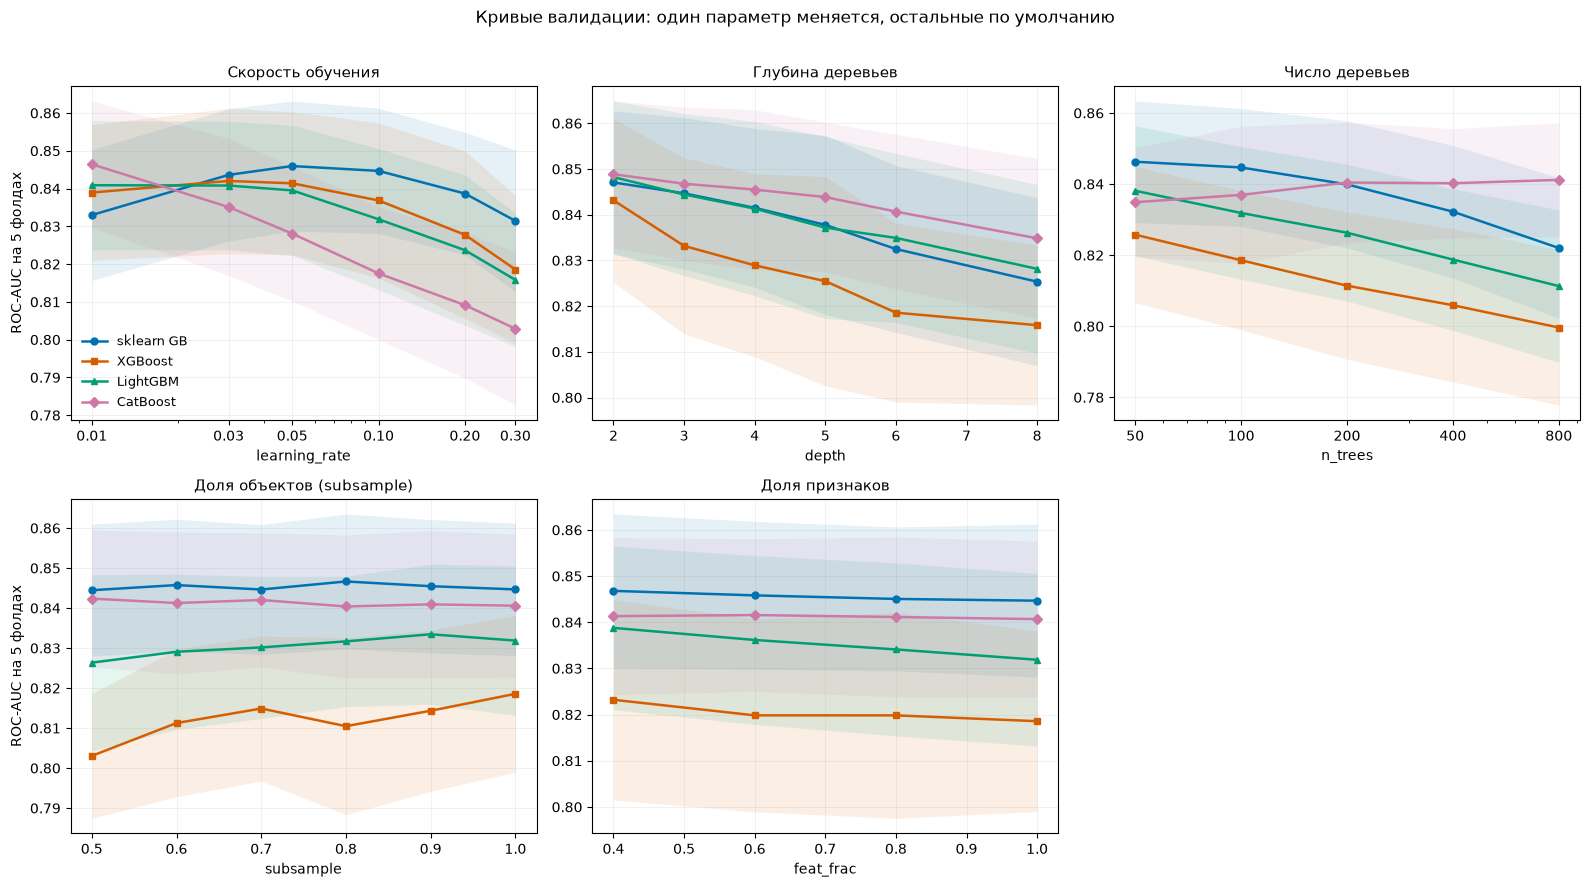

In [29]:
TITLES = {
    "learning_rate": "Скорость обучения",
    "depth":         "Глубина деревьев",
    "n_trees":       "Число деревьев",
    "subsample":     "Доля объектов (subsample)",
    "feat_frac":     "Доля признаков",
}
LOG_X = {"learning_rate", "n_trees"}


def set_log_ticks(ax, values):
    """Логарифмическая ось с подписями только в заданных точках.
    Без NullFormatter matplotlib рисует ещё и вспомогательные деления
    (4x10^2 и подобные), которые наезжают на наши подписи."""
    ax.set_xscale("log")
    ax.set_xticks(values)
    ax.get_xaxis().set_major_formatter(plt.matplotlib.ticker.ScalarFormatter())
    ax.get_xaxis().set_minor_formatter(plt.matplotlib.ticker.NullFormatter())


fig, axes = plt.subplots(2, 3, figsize=(16, 9))
flat = axes.ravel()

for ax, param in zip(flat, SWEEPS):
    for lib, (color, marker) in LIB_STYLE.items():
        v, m, s = curves[(lib, param)]
        ax.plot(v, m, color=color, marker=marker, lw=1.8, ms=5, label=lib)
        ax.fill_between(v, m - s, m + s, color=color, alpha=0.10, lw=0)

    ax.set_title(TITLES[param], fontsize=11)
    ax.set_xlabel(param)
    if param in LOG_X:
        set_log_ticks(ax, SWEEPS[param])
    ax.grid(alpha=0.25, linewidth=0.5)
    ax.set_axisbelow(True)

flat[0].set_ylabel("ROC-AUC на 5 фолдах")
flat[3].set_ylabel("ROC-AUC на 5 фолдах")
flat[0].legend(frameon=False, fontsize=9)
flat[-1].axis("off")   # шестая клетка не нужна: параметров пять

fig.suptitle("Кривые валидации: один параметр меняется, остальные по умолчанию", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### Шаг 2. GridSearchCV с равным бюджетом

Кривые выше показывают влияние параметров по отдельности, но параметры связаны между собой: при мелком шаге нужно больше деревьев, при большей глубине — сильнее регуляризация. Поэтому перебираем их совместно.

**Диапазоны выбраны по кривым из Шага 1**, и они смещены заметно ниже дефолтов. Кривые показывают монотонное падение качества при росте глубины (лучше всего 2), при росте числа деревьев (лучше всего 50) и при шаге больше 0,05. Поэтому сетка накрывает область слабых, сильно регуляризованных моделей:

```
learning_rate  0.01  0.03  0.05
depth          2     3     4
n_trees        50    100   200
subsample      0.8   1.0          плато по кривым, хватает двух значений
feat_frac      0.4   0.6   0.8
```

По каждому параметру берём три значения (кроме `subsample`, где кривая плоская). По двум точкам виден только знак разницы, но не форма зависимости: нельзя отличить плато от роста и нельзя заметить оптимум внутри диапазона.

Сетка одинаковая для всех четырёх библиотек — 3 × 3 × 3 × 2 × 3 = **162 комбинации** на каждую, по 5 фолдов, то есть 810 обучений на библиотеку. Равный бюджет обязателен: иначе сравнение покажет, кому досталось больше вычислений.

Почему все три параметра тянут в одну сторону: способность модели подгоняться определяется примерно произведением «шаг × число деревьев × глубина». Все три уменьшают её одновременно, и на наших данных выигрывает минимальная из перебранных. Это согласуется с потолком качества из п. 6 выводов EDA — при 42 строках с противоречивой разметкой подгоняться некуда, и любая лишняя свобода уходит в переобучение.

Разделение задач между шагами: кривые из Шага 1 нужны, чтобы понять тенденцию, сетка — чтобы выбрать лучшую комбинацию. Тенденцию по сетке тоже посмотрим, но иначе: усреднением по всем остальным параметрам.

In [30]:
GRID = {
    "learning_rate": [0.01, 0.03, 0.05],
    "depth":         [2, 3, 4],
    "n_trees":       [50, 100, 200],
    "subsample":     [0.8, 1.0],
    "feat_frac":     [0.4, 0.6, 0.8],
}
LR, DEPTH, NTREES, SUB, FF = (GRID["learning_rate"], GRID["depth"],
                              GRID["n_trees"], GRID["subsample"], GRID["feat_frac"])

# Соответствие логического имени фактическому — понадобится для графика влияния.
NATIVE_NAME = {
    "sklearn GB": {"learning_rate": "learning_rate", "depth": "max_depth",
                   "n_trees": "n_estimators", "subsample": "subsample",
                   "feat_frac": "max_features"},
    "XGBoost":    {"learning_rate": "learning_rate", "depth": "max_depth",
                   "n_trees": "n_estimators", "subsample": "subsample",
                   "feat_frac": "colsample_bytree"},
    "LightGBM":   {"learning_rate": "learning_rate", "depth": "num_leaves",
                   "n_trees": "n_estimators", "subsample": "subsample",
                   "feat_frac": "colsample_bytree"},
    "CatBoost":   {"learning_rate": "learning_rate", "depth": "depth",
                   "n_trees": "iterations", "subsample": "subsample",
                   "feat_frac": "rsm"},
}


def native_grid(lib):
    """Возвращает (модель, сетка) с фактическими именами параметров библиотеки.
    Сетки записаны явно: автоматический вывод имён ломается там, где одно
    логическое значение задаётся двумя параметрами."""
    if lib == "sklearn GB":
        return GradientBoostingClassifier(random_state=RANDOM_STATE), {
            "learning_rate": LR, "max_depth": DEPTH, "n_estimators": NTREES,
            "subsample": SUB, "max_features": FF}

    if lib == "XGBoost":
        return XGBClassifier(random_state=RANDOM_STATE, n_jobs=1), {
            "learning_rate": LR, "max_depth": DEPTH, "n_estimators": NTREES,
            "subsample": SUB, "colsample_bytree": FF}

    if lib == "LightGBM":
        # Глубину задаём через num_leaves = 2^depth. Перебирать max_depth
        # при фиксированном num_leaves бессмысленно: ограничение придёт от листьев.
        # subsample_freq=1 — иначе subsample игнорируется.
        return LGBMClassifier(random_state=RANDOM_STATE, verbose=-1, n_jobs=1,
                              subsample_freq=1), {
            "learning_rate": LR, "num_leaves": [2 ** d for d in DEPTH],
            "n_estimators": NTREES, "subsample": SUB, "colsample_bytree": FF}

    if lib == "CatBoost":
        # bootstrap_type="Bernoulli" — иначе subsample не действует.
        return CatBoostClassifier(random_state=RANDOM_STATE, verbose=0, thread_count=1,
                                  bootstrap_type="Bernoulli"), {
            "learning_rate": LR, "depth": DEPTH, "iterations": NTREES,
            "subsample": SUB, "rsm": FF}

    raise ValueError(lib)


searches, tuned_rows = {}, []

for lib in LIB_STYLE:
    model, grid = native_grid(lib)
    n_comb = int(np.prod([len(v) for v in grid.values()]))

    t0 = perf_counter()
    gs = GridSearchCV(model, grid, cv=cv_tune, scoring="roc_auc", n_jobs=-1, refit=True)
    gs.fit(X_train, y_train)
    elapsed = perf_counter() - t0

    searches[lib] = gs
    cv_before = baseline.loc[baseline["модель"] == lib, "ROC-AUC"].iloc[0]
    tuned_rows.append({
        "модель":     lib,
        "CV до":      cv_before,
        "CV после":   gs.best_score_,
        "std после":  gs.cv_results_["std_test_score"][gs.best_index_],
        "прирост":    gs.best_score_ - cv_before,
        "перебор, с": elapsed,
    })
    print(f"{lib:11} {n_comb} комбинаций за {elapsed:6.1f} c | лучший CV ROC-AUC = {gs.best_score_:.4f}")

tuned = pd.DataFrame(tuned_rows).sort_values("CV после", ascending=False).reset_index(drop=True)
print()
print(tuned.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print("\nЛучшие параметры:")
for lib in LIB_STYLE:
    print(f"  {lib:11} {searches[lib].best_params_}")

sklearn GB  162 комбинаций за   29.5 c | лучший CV ROC-AUC = 0.8490


XGBoost     162 комбинаций за    3.3 c | лучший CV ROC-AUC = 0.8510


LightGBM    162 комбинаций за    4.5 c | лучший CV ROC-AUC = 0.8507


CatBoost    162 комбинаций за    9.3 c | лучший CV ROC-AUC = 0.8504

    модель  CV до  CV после  std после  прирост  перебор, с
   XGBoost 0.8178    0.8510     0.0177   0.0332      3.3325
  LightGBM 0.8317    0.8507     0.0169   0.0189      4.4565
  CatBoost 0.8400    0.8504     0.0162   0.0104      9.3209
sklearn GB 0.8445    0.8490     0.0166   0.0045     29.5186

Лучшие параметры:
  sklearn GB  {'learning_rate': 0.05, 'max_depth': 2, 'max_features': 0.4, 'n_estimators': 200, 'subsample': 0.8}
  XGBoost     {'colsample_bytree': 0.4, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
  LightGBM    {'colsample_bytree': 0.4, 'learning_rate': 0.05, 'n_estimators': 100, 'num_leaves': 8, 'subsample': 1.0}
  CatBoost    {'depth': 4, 'iterations': 200, 'learning_rate': 0.05, 'rsm': 0.4, 'subsample': 1.0}


### Шаг 3. Влияние параметров внутри полного перебора

Кривые из Шага 1 меняли один параметр, а остальные держали на значениях по умолчанию. Такой замер зависит от того, какие именно дефолты у библиотеки, и потому у XGBoost с шагом 0,3 картина искажена.

Здесь берём результаты сетки и для каждого значения параметра усредняем ROC-AUC по всем комбинациям остальных четырёх. Это устраняет привязку к дефолтам: каждое значение оценивается в среднем по всему пространству остальных настроек.

Линия «лучшее» показывает максимум по остальным параметрам, а не среднее. Разница между линиями важна: если среднее падает, а максимум держится, значит параметр не вреден сам по себе, но требует согласования с другими.

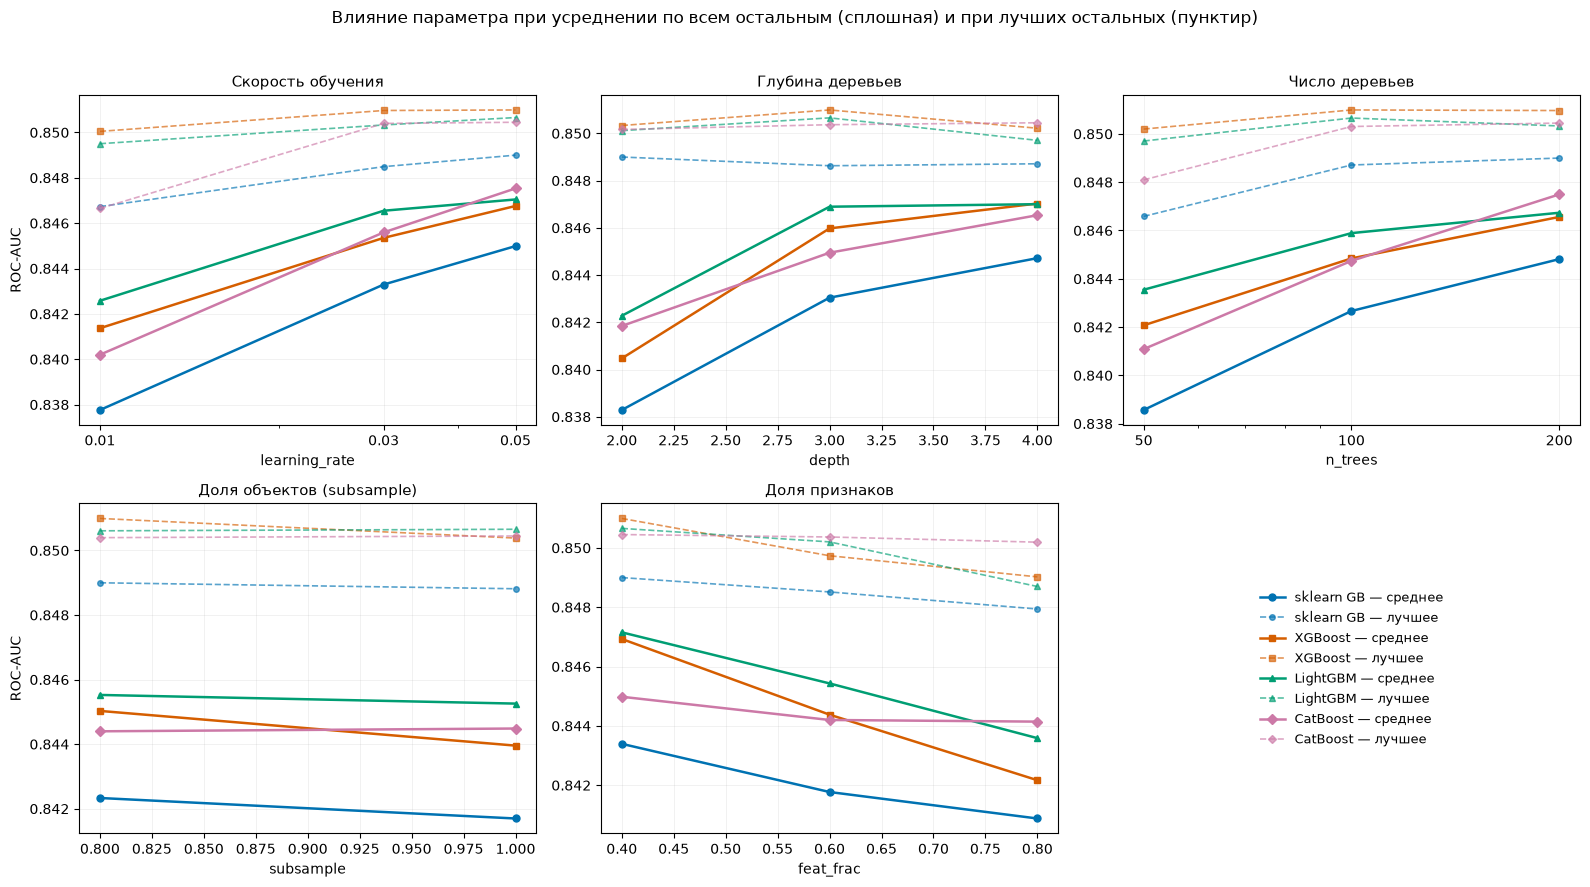

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
flat = axes.ravel()

for ax, param in zip(flat, GRID):
    for lib, (color, marker) in LIB_STYLE.items():
        res = pd.DataFrame(searches[lib].cv_results_)
        col = "param_" + NATIVE_NAME[lib][param]

        # Для LightGBM глубина задана через num_leaves — приводим к глубине,
        # иначе ось X у одной библиотеки будет в других единицах.
        vals = res[col].astype(float)
        if param == "depth" and lib == "LightGBM":
            vals = np.log2(vals)

        agg = (res.assign(v=vals)
                  .groupby("v")["mean_test_score"]
                  .agg(["mean", "max"])
                  .sort_index())

        ax.plot(agg.index, agg["mean"], color=color, marker=marker, lw=1.8, ms=5,
                label=f"{lib} — среднее")
        ax.plot(agg.index, agg["max"], color=color, marker=marker, lw=1.2, ms=4,
                ls="--", alpha=0.65, label=f"{lib} — лучшее")

    ax.set_title(TITLES[param], fontsize=11)
    ax.set_xlabel(param)
    if param in LOG_X:
        set_log_ticks(ax, GRID[param])
    ax.grid(alpha=0.25, linewidth=0.5)
    ax.set_axisbelow(True)

flat[0].set_ylabel("ROC-AUC")
flat[3].set_ylabel("ROC-AUC")
flat[-1].axis("off")
flat[-1].legend(*flat[0].get_legend_handles_labels(), loc="center", frameon=False, fontsize=9)

fig.suptitle("Влияние параметра при усреднении по всем остальным (сплошная) и при лучших остальных (пунктир)",
             fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Шаг 4. Настроенные модели на отложенной выборке

Берём лучшую комбинацию каждой библиотеки, обучаем на всём train и проверяем на тех же 1405 отложенных строках. Это первое и единственное обращение к тесту после настройки.

Дополнительно повторяем парное сравнение — на 15 фолдах и бутстрэпом на тесте, теми же методами, что и для дефолтных моделей. Это и есть проверка рабочей гипотезы: если после настройки различия перестанут быть значимыми, значит прежний разрыв объяснялся дефолтами.

In [32]:
tuned_fold_scores, tuned_test_preds, rows = {}, {}, []

for lib in LIB_STYLE:
    best = searches[lib].best_estimator_

    # Повторная кросс-валидация на тех же 15 фолдах, что и для дефолтных моделей.
    cvr = cross_validate(best, X_train, y_train, cv=cv_eval, scoring=SCORING, n_jobs=-1)
    tuned_fold_scores[lib] = cvr["test_roc_auc"]

    best.fit(X_train, y_train)
    proba = best.predict_proba(X_test)[:, 1]
    tuned_test_preds[lib] = proba

    rows.append({
        "модель":       lib,
        "CV до":        baseline.loc[baseline["модель"] == lib, "ROC-AUC"].iloc[0],
        "CV после":     cvr["test_roc_auc"].mean(),
        "std после":    cvr["test_roc_auc"].std(),
        "TEST до":      holdout.loc[holdout["модель"] == lib, "TEST ROC-AUC"].iloc[0],
        "TEST после":   roc_auc_score(y_test, proba),
        "TEST PR-AUC":  average_precision_score(y_test, proba),
    })

final = pd.DataFrame(rows).sort_values("CV после", ascending=False).reset_index(drop=True)
print(final.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

# Парный тест на 15 фолдах: сравниваем всех с лидером после настройки
leader = final.loc[0, "модель"]
print(f"\nПарный t-тест на 15 фолдах, лидер {leader}:\n")
for lib in final["модель"][1:]:
    d = tuned_fold_scores[leader] - tuned_fold_scores[lib]
    _, p = stats.ttest_rel(tuned_fold_scores[leader], tuned_fold_scores[lib])
    verdict = "значимо" if p < 0.05 else "НЕ значимо"
    print(f"  {leader} - {lib:11} {d.mean():+.4f}  p = {p:8.1e}  побед {int((d > 0).sum()):2d}/15  {verdict}")

# Бутстрэп на тесте — те же пересэмплирования, что и для дефолтных моделей
boot_tuned = {n: np.array([roc_auc_score(y_test_arr[i], p[i]) for i in boot_idx])
              for n, p in tuned_test_preds.items()}
print("\nБутстрэп на тесте, парные разности:\n")
names = list(final["модель"])
for i, a in enumerate(names):
    for b_name in names[i + 1:]:
        d = boot_tuned[a] - boot_tuned[b_name]
        lo, hi = np.percentile(d, [2.5, 97.5])
        verdict = "значимо" if lo > 0 or hi < 0 else "НЕ значимо"
        print(f"  {a:11} - {b_name:11} {d.mean():+.4f}  [{lo:+.4f}, {hi:+.4f}]  {verdict}")

    модель  CV до  CV после  std после  TEST до  TEST после  TEST PR-AUC
   XGBoost 0.8178    0.8497     0.0135   0.8137      0.8433       0.6573
  LightGBM 0.8317    0.8493     0.0131   0.8318      0.8453       0.6583
  CatBoost 0.8400    0.8491     0.0129   0.8374      0.8450       0.6567
sklearn GB 0.8445    0.8477     0.0128   0.8372      0.8418       0.6561

Парный t-тест на 15 фолдах, лидер XGBoost:

  XGBoost - LightGBM    +0.0005  p =  4.4e-01  побед  9/15  НЕ значимо
  XGBoost - CatBoost    +0.0007  p =  3.5e-01  побед  9/15  НЕ значимо
  XGBoost - sklearn GB  +0.0021  p =  2.8e-03  побед 11/15  значимо



Бутстрэп на тесте, парные разности:

  XGBoost     - LightGBM    -0.0020  [-0.0047, +0.0007]  НЕ значимо
  XGBoost     - CatBoost    -0.0016  [-0.0050, +0.0018]  НЕ значимо
  XGBoost     - sklearn GB  +0.0015  [-0.0015, +0.0044]  НЕ значимо
  LightGBM    - CatBoost    +0.0004  [-0.0034, +0.0039]  НЕ значимо
  LightGBM    - sklearn GB  +0.0035  [-0.0000, +0.0071]  НЕ значимо
  CatBoost    - sklearn GB  +0.0031  [-0.0004, +0.0066]  НЕ значимо


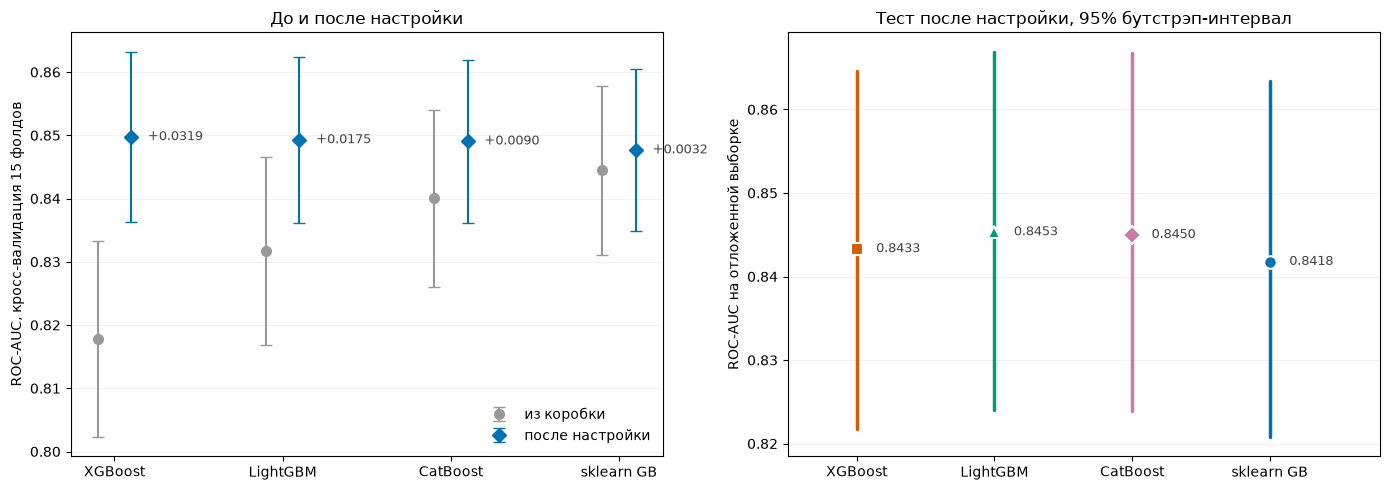

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order = list(final["модель"])
xs = np.arange(len(order))

# Слева: до и после настройки на кросс-валидации, с усами разброса по фолдам
ax = axes[0]
before = [baseline.loc[baseline["модель"] == m, "ROC-AUC"].iloc[0] for m in order]
before_std = [baseline.loc[baseline["модель"] == m, "std"].iloc[0] for m in order]
after = [final.loc[final["модель"] == m, "CV после"].iloc[0] for m in order]
after_std = [final.loc[final["модель"] == m, "std после"].iloc[0] for m in order]

ax.errorbar(xs - 0.10, before, yerr=before_std, fmt="o", ms=7, capsize=4,
            color="#999999", label="из коробки")
ax.errorbar(xs + 0.10, after, yerr=after_std, fmt="D", ms=7, capsize=4,
            color="#0072B2", label="после настройки")
for x, b, a in zip(xs, before, after):
    ax.annotate(f"{a - b:+.4f}", (x + 0.10, a), textcoords="offset points",
                xytext=(12, 0), fontsize=9, va="center", color="#444")

ax.set_xticks(xs)
ax.set_xticklabels(order)
ax.set_ylabel("ROC-AUC, кросс-валидация 15 фолдов")
ax.set_title("До и после настройки")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.25, linewidth=0.5)
ax.set_axisbelow(True)

# Справа: тест с бутстрэп-интервалами
ax = axes[1]
for i, m in enumerate(order):
    b = boot_tuned[m]
    lo, hi = np.percentile(b, [2.5, 97.5])
    point = roc_auc_score(y_test_arr, tuned_test_preds[m])
    color = LIB_STYLE[m][0]
    ax.plot([i, i], [lo, hi], color=color, lw=2.5, solid_capstyle="round")
    ax.plot(i, point, marker=LIB_STYLE[m][1], ms=9, color=color,
            markeredgecolor="white", markeredgewidth=1.5)
    ax.annotate(f"{point:.4f}", (i, point), textcoords="offset points",
                xytext=(14, 0), fontsize=9, va="center", color="#444")

ax.set_xticks(xs)
ax.set_xticklabels(order)
ax.set_xlim(-0.5, len(order) - 0.2)
ax.set_ylabel("ROC-AUC на отложенной выборке")
ax.set_title("Тест после настройки, 95% бутстрэп-интервал")
ax.grid(axis="y", alpha=0.25, linewidth=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## Дополнительные проверки

Нумерация шагов своя.

### Шаг 1. Какие признаки можно убрать

Проверяем замером то, что раньше решалось рассуждением. Сравниваем шесть наборов признаков на одних и тех же 15 фолдах, каждый — всеми четырьмя настроенными моделями.

| набор | признаков | что проверяем |
|---|---|---|
| базовый | 20 | точка отсчёта |
| без `TotalCharges` | 19 | коллинеарный признак, корреляция 0,9996 с `tenure × MonthlyCharges` |
| без `ChargesRatio` | 19 | производный признак, добавленный нами в Шаге 5 |
| без обоих | 18 | остаются только `tenure` и `MonthlyCharges` |
| без `tenure` и `MonthlyCharges` | 18 | обратный вариант: оставить произведение, убрать множители |
| с `gender` | 21 | признак, исключённый по цифрам EDA без замера |

Два последних набора требуют пояснения.

**Вариант "убрать множители, оставить произведение".** Связь `TotalCharges ≈ tenure × MonthlyCharges` симметрична, поэтому формально убрать можно любую из трёх величин. Но деревья не умеют делить: чтобы восстановить срок обслуживания, модели пришлось бы вычислить `TotalCharges / MonthlyCharges`, а из операций у неё только сравнение с порогом. Клиент с `TotalCharges = 1200` — это либо 12 месяцев по 100, либо 60 месяцев по 20, и риск оттока у них противоположный. Ожидаем падение, но проверяем замером.

**Вариант "с `gender`".** В Шаге 5 предобработки признак исключён из `X` по разбросу доли оттока 0,8 п.п., но оставлен в `data`. Здесь возвращаем его и смотрим, теряем ли мы что-нибудь от его отсутствия.

**Гиперпараметры берём подобранные на базовом наборе**, заново не настраиваем. Строго правильно было бы перенастраивать под каждый набор, но это в шесть раз дороже. При таком приближении мы отвечаем на вопрос "мешает ли признак при фиксированных настройках", а не "изменится ли оптимум без него".

In [34]:
from sklearn.base import clone

BASE_FEATURES = NUM_FEATURES + CAT_FEATURES

# gender лежит в data незакодированным — кодируем так же, как остальные категории.
gender_encoded = pd.Series(LabelEncoder().fit_transform(data["gender"]),
                           index=data.index, name="gender")
X_full = X.join(gender_encoded)

FEATURE_SETS = {
    "базовый":                     BASE_FEATURES,
    "без TotalCharges":            [c for c in BASE_FEATURES if c != "TotalCharges"],
    "без ChargesRatio":            [c for c in BASE_FEATURES if c != "ChargesRatio"],
    "без обоих":                   [c for c in BASE_FEATURES
                                    if c not in ("TotalCharges", "ChargesRatio")],
    "без tenure и MonthlyCharges": [c for c in BASE_FEATURES
                                    if c not in ("tenure", "MonthlyCharges")],
    "с gender":                    BASE_FEATURES + ["gender"],
}

rows = []
for set_name, cols in FEATURE_SETS.items():
    t0 = perf_counter()
    for lib in LIB_STYLE:
        # clone: берём подобранные гиперпараметры, но необученную копию модели
        s = cross_val_score(clone(searches[lib].best_estimator_),
                            X_full.loc[X_train.index, cols], y_train,
                            cv=cv_eval, scoring="roc_auc", n_jobs=-1)
        rows.append({"набор": set_name, "признаков": len(cols),
                     "модель": lib, "ROC-AUC": s.mean(), "std": s.std()})
    print(f"{set_name:28} {len(cols):2d} признаков  за {perf_counter() - t0:5.1f} c")

fs = pd.DataFrame(rows)
fs_pivot = (fs.pivot(index="набор", columns="модель", values="ROC-AUC")
              .reindex(FEATURE_SETS.keys())[list(LIB_STYLE)])
fs_pivot["среднее"] = fs_pivot.mean(axis=1)
fs_pivot["к базовому"] = fs_pivot["среднее"] - fs_pivot.loc["базовый", "среднее"]

print()
print(fs_pivot.to_string(float_format=lambda v: f"{v:+.4f}" if abs(v) < 0.1 else f"{v:.4f}"))
print(f"\nразброс по фолдам для сравнения: {fs['std'].mean():.4f}")

базовый                      20 признаков  за   1.3 c


без TotalCharges             19 признаков  за   1.2 c


без ChargesRatio             19 признаков  за   1.2 c


без обоих                    18 признаков  за   1.1 c


без tenure и MonthlyCharges  18 признаков  за   1.2 c


с gender                     21 признаков  за   1.3 c

модель                       sklearn GB  XGBoost  LightGBM  CatBoost  среднее  к базовому
набор                                                                                    
базовый                          0.8477   0.8497    0.8493    0.8491   0.8489     +0.0000
без TotalCharges                 0.8472   0.8485    0.8474    0.8483   0.8479     -0.0011
без ChargesRatio                 0.8480   0.8493    0.8483    0.8489   0.8486     -0.0003
без обоих                        0.8474   0.8481    0.8479    0.8482   0.8479     -0.0010
без tenure и MonthlyCharges      0.8479   0.8481    0.8491    0.8482   0.8483     -0.0006
с gender                         0.8476   0.8491    0.8487    0.8484   0.8484     -0.0005

разброс по фолдам для сравнения: 0.0130


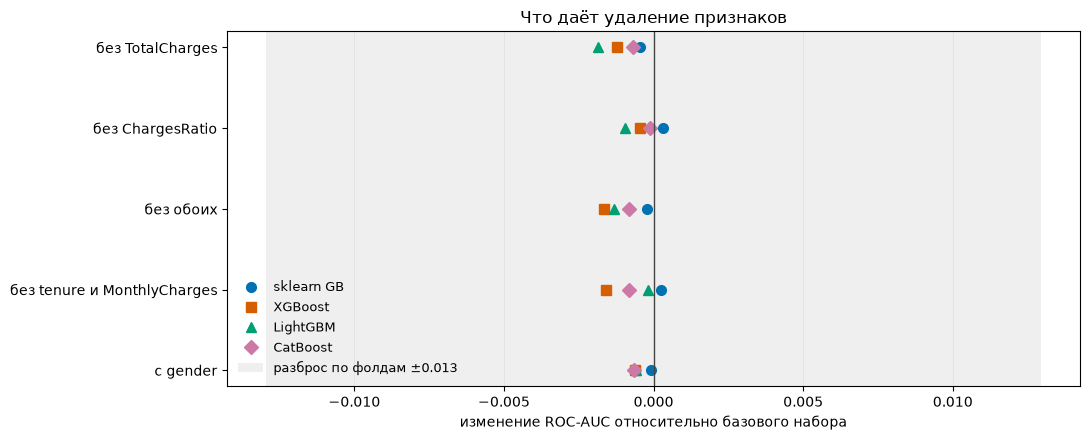

In [35]:
fig, ax = plt.subplots(figsize=(11, 4.5))

order = [s for s in FEATURE_SETS if s != "базовый"]
ys = np.arange(len(order))

for lib, (color, marker) in LIB_STYLE.items():
    deltas = [fs_pivot.loc[s, lib] - fs_pivot.loc["базовый", lib] for s in order]
    ax.plot(deltas, ys, marker=marker, ms=7, ls="none", color=color, label=lib)

# Полоса шума: типичный разброс по фолдам. Всё, что внутри неё, неотличимо от нуля.
noise = fs["std"].mean()
ax.axvspan(-noise, noise, color="#999999", alpha=0.15, lw=0,
           label=f"разброс по фолдам ±{noise:.3f}")
ax.axvline(0, color="#444444", lw=1)

ax.set_yticks(ys)
ax.set_yticklabels(order)
ax.invert_yaxis()
ax.set_xlabel("изменение ROC-AUC относительно базового набора")
ax.set_title("Что даёт удаление признаков")
ax.legend(frameon=False, fontsize=9, loc="lower left")
ax.grid(axis="x", alpha=0.25, linewidth=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Шаг 2. Нижняя граница: логистическая регрессия

Публикации по этому датасету сообщают, что логистическая регрессия даёт ROC-AUC 0,842–0,852, то есть попадает в тот же диапазон, что и бустинг. Если это подтвердится, вывод работы усилится: на таких данных бустинг не нужен вовсе.

**Логистической регрессии требуется другая предобработка**, и это хорошая иллюстрация к разделу "Чего мы сознательно не делаем":

- **масштабирование обязательно** — модель считает взвешенную сумму, и признак с диапазоном 0…8684 подавил бы признак с диапазоном 0…72;
- **one-hot вместо целых меток обязателен** — метки `LabelEncoder` линейная модель истолкует как числа с порядком, то есть решит, что "почтовый чек" втрое больше "карты".

Для деревьев ни то, ни другое не требовалось. Здесь требуется, поэтому собираем `Pipeline` с `ColumnTransformer`: масштабирование числовых плюс one-hot категориальных. Внутри кросс-валидации оба шага пересчитываются на каждом фолде отдельно, так что подглядывания в валидационную часть не происходит.

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

lr_pipe = Pipeline([
    ("prep", ColumnTransformer([
        ("num", StandardScaler(), NUM_FEATURES),
        # drop="first" убирает одну колонку на признак: при полном наборе дамми
        # сумма всегда равна единице, и матрица становится вырожденной.
        ("cat", OneHotEncoder(drop="first", sparse_output=False), CAT_FEATURES),
    ])),
    ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])

cvr = cross_validate(lr_pipe, X_train, y_train, cv=cv_eval, scoring=SCORING, n_jobs=-1)
lr_folds = cvr["test_roc_auc"]

lr_pipe.fit(X_train, y_train)
lr_proba = lr_pipe.predict_proba(X_test)[:, 1]

rows = [{"модель": "LogisticRegression",
         "CV ROC-AUC": lr_folds.mean(), "std": lr_folds.std(),
         "TEST ROC-AUC": roc_auc_score(y_test, lr_proba),
         "TEST PR-AUC": average_precision_score(y_test, lr_proba)}]
for lib in final["модель"]:
    rows.append({"модель": lib,
                 "CV ROC-AUC": final.loc[final["модель"] == lib, "CV после"].iloc[0],
                 "std": final.loc[final["модель"] == lib, "std после"].iloc[0],
                 "TEST ROC-AUC": final.loc[final["модель"] == lib, "TEST после"].iloc[0],
                 "TEST PR-AUC": final.loc[final["модель"] == lib, "TEST PR-AUC"].iloc[0]})

cmp = pd.DataFrame(rows).sort_values("CV ROC-AUC", ascending=False).reset_index(drop=True)
print(cmp.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

# Парное сравнение с лучшим бустингом на тех же 15 фолдах
best_boost = final.loc[0, "модель"]
d = tuned_fold_scores[best_boost] - lr_folds
_, p = stats.ttest_rel(tuned_fold_scores[best_boost], lr_folds)
print(f"\n{best_boost} - LogisticRegression: {d.mean():+.4f}  p = {p:.3f}  "
      f"побед {int((d > 0).sum())}/15  "
      f"{'значимо' if p < 0.05 else 'НЕ значимо'}")

# И бутстрэпом на тесте, теми же пересэмплированиями
boot_lr = np.array([roc_auc_score(y_test_arr[i], lr_proba[i]) for i in boot_idx])
dd = boot_tuned[best_boost] - boot_lr
lo, hi = np.percentile(dd, [2.5, 97.5])
print(f"на тесте (бутстрэп):   {dd.mean():+.4f}  [{lo:+.4f}, {hi:+.4f}]  "
      f"{'значимо' if lo > 0 or hi < 0 else 'НЕ значимо'}")

            модель  CV ROC-AUC    std  TEST ROC-AUC  TEST PR-AUC
           XGBoost      0.8497 0.0135        0.8433       0.6573
          LightGBM      0.8493 0.0131        0.8453       0.6583
          CatBoost      0.8491 0.0129        0.8450       0.6567
        sklearn GB      0.8477 0.0128        0.8418       0.6561
LogisticRegression      0.8456 0.0120        0.8405       0.6365

XGBoost - LogisticRegression: +0.0041  p = 0.005  побед 12/15  значимо


на тесте (бутстрэп):   +0.0029  [-0.0041, +0.0101]  НЕ значимо


## Итоговые выводы

### Результаты настройки

Все значения ROC-AUC посчитаны на одних и тех же 15 фолдах (5 разбиений × 3 повтора), чтобы «до» и «после» были сравнимы.

| модель | CV до | CV после | прирост | TEST до | TEST после | TEST PR-AUC | перебор, с |
|---|---|---|---|---|---|---|---|
| XGBoost | 0,8178 | **0,8497** | **+0,0319** | 0,8137 | 0,8433 | 0,6573 | **3,3** |
| LightGBM | 0,8317 | 0,8493 | +0,0176 | 0,8318 | **0,8453** | **0,6583** | 4,5 |
| CatBoost | 0,8400 | 0,8491 | +0,0091 | 0,8374 | 0,8450 | 0,6567 | 9,3 |
| sklearn GB | **0,8445** | 0,8477 | +0,0032 | 0,8372 | 0,8418 | 0,6561 | **29,5** |

### Рабочая гипотеза подтвердилась

Разброс между библиотеками сократился с **0,0267 до 0,0020** на кросс-валидации. Порядок полностью перевернулся: XGBoost переехал с последнего места на первое, sklearn GB — с первого на последнее.

Прирост обратно пропорционален качеству дефолтов. XGBoost с самыми агрессивными настройками (шаг 0,3, глубина 6) вырос на 0,0319, sklearn GB с уже консервативными дефолтами — на 0,0032, в десять раз меньше. Это подтверждает вывод этапа "из коробки": там сравнивались не алгоритмы, а осторожность значений по умолчанию.

### Различий между библиотеками не обнаружено

**На отложенной выборке ни одна пара не различима.** Все шесть бутстрэп-интервалов разностей накрывают ноль, включая пары с sklearn GB.

**На кросс-валидации** (парный t-тест, лидер XGBoost): с LightGBM +0,0005 при p = 0,44, с CatBoost +0,0007 при p = 0,35 — различий нет. Значима только разница с sklearn GB: +0,0021 при p = 0,003 и 11 победах из 15.

То есть **XGBoost, LightGBM и CatBoost неразличимы** обоими методами. sklearn GB отстаёт на 0,0021, что подтверждается кросс-валидацией, но не подтверждается тестом.

Для масштаба: разброс каждой модели по фолдам около 0,013, ширина 95% интервала на тесте около 0,043. Все обнаруженные различия на порядок меньше собственной погрешности измерения.

### Все четыре библиотеки сошлись к одним настройкам

| модель | learning_rate | глубина | деревьев | subsample | доля признаков |
|---|---|---|---|---|---|
| sklearn GB | 0,05 | 2 | 200 | 0,8 | 0,4 |
| XGBoost | 0,05 | 3 | 100 | 0,8 | 0,4 |
| LightGBM | 0,05 | 3 (8 листьев) | 100 | 1,0 | 0,4 |
| CatBoost | 0,05 | 4 | 200 | 1,0 | 0,4 |

Скорость обучения 0,05 и доля признаков 0,4 выбраны **всеми четырьмя**, глубина попала в узкий диапазон 2…4, число деревьев — 100 или 200. Оптимум задан свойствами данных, а не устройством библиотеки.

Везде выиграли сильно регуляризованные варианты: глубина 2–4 против дефолтных 6, сотни деревьев вместо тысячи. Это согласуется с потолком качества из п. 6 выводов EDA — при 42 строках с противоречивой разметкой подгоняться некуда, и лишняя свобода уходит в переобучение.

**Про границы сетки.** Первая версия сетки была шире и выше (`depth` 3–6, `n_trees` 200–1000, `learning_rate` 0,03–0,1); в ней оптимум упирался в нижний край по трём параметрам. Вторая версия смещена вниз, и в ней те же параметры упираются в верхний край. Два прогона с противоположных сторон **зажимают оптимум**: шаг около 0,05, глубина 3–4, деревьев около 200. Незажатой осталась только доля признаков — она выбрана минимальной в обеих сетках, поэтому настоящий оптимум может лежать ниже 0,4.

### Ни один признак удалить нельзя — и ни один не мешает

Шесть наборов признаков, каждый прогнан всеми четырьмя настроенными моделями на тех же 15 фолдах:

| набор | признаков | среднее ROC-AUC | к базовому |
|---|---|---|---|
| базовый | 20 | 0,8489 | — |
| без `ChargesRatio` | 19 | 0,8486 | −0,0003 |
| с `gender` | 21 | 0,8484 | −0,0005 |
| без `tenure` и `MonthlyCharges` | 18 | 0,8483 | −0,0006 |
| без обоих производных | 18 | 0,8479 | −0,0010 |
| без `TotalCharges` | 19 | 0,8479 | −0,0011 |

Максимальное изменение — 0,0011 при разбросе по фолдам 0,0130, то есть в двенадцать раз меньше шума. **Ни одно удаление и ни одно добавление не влияет на качество.**

Что это означает по пунктам:

- **`TotalCharges` можно оставить или убрать** — коллинеарность с `tenure × MonthlyCharges` (корреляция 0,9996) на качество не влияет, что и ожидалось для деревьев.
- **Удаление `gender` в предобработке оправдано** — теперь это подтверждено замером, а не только разбросом доли оттока в EDA.
- **`ChargesRatio`, добавленный нами, не пригодился** — прироста от него нет.
- **Прогноз про `tenure` и `MonthlyCharges` не подтвердился.** Ожидалось заметное падение: деревья не умеют делить, и без множителей срок обслуживания из произведения не восстановить. Фактически потеря составила 0,0006, то есть ноль. Объяснение: основной сигнал несут категориальные признаки (`Contract`, `InternetService`, `PaymentMethod` — разброс доли оттока 30–40 п.п. по п. 11 выводов EDA), и числовая тройка во многом дублирует их.

### Бустинг почти не превосходит логистическую регрессию в данном случае

| модель | CV ROC-AUC | TEST ROC-AUC | TEST PR-AUC |
|---|---|---|---|
| XGBoost | 0,8497 | 0,8433 | 0,6573 |
| LogisticRegression | 0,8456 | 0,8405 | 0,6365 |

Разница на кросс-валидации +0,0041 при p = 0,005 и 12 победах из 15 — формально значимая. На тесте бутстрэп даёт +0,0029 с интервалом от −0,0041 до +0,0101, то есть не значимо.

Линейная модель отстаёт на 0,004 ROC-AUC. Это согласуется с публикациями по этому датасету, где логистическая регрессия показывает 0,842–0,852.

Заметнее разрыв по PR-AUC: 0,6573 против 0,6365, то есть 0,021. Метрика, чувствительная к редкому классу, различает модели лучше — и именно там бустинг даёт единственное практически заметное преимущество.

### Ответ на вопрос задания

**Качество.** На данных Telco Customer Churn после настройки все четыре реализации дают одинаковый результат: 0,848–0,850 ROC-AUC на кросс-валидации и 0,842–0,845 на отложенной выборке. Достоверных различий между XGBoost, LightGBM и CatBoost нет ни по одному из двух методов проверки.

**Скорость.** Здесь различия реальные и крупные. Одинаковый перебор из 162 комбинаций: XGBoost 3,3 с, LightGBM 4,5 с, CatBoost 9,3 с, sklearn GB 29,5 с — разница в **9 раз** при одинаковом качестве.

**Практический вывод: выбирать по скорости.** XGBoost и LightGBM дают тот же результат в 2–9 раз быстрее остальных. `GradientBoostingClassifier` из sklearn проигрывает по скорости и не выигрывает по качеству.

**Предсказание из EDA оказалось верным.** изначально было предположение, что преимущество CatBoost не проявится, поскольку кардинальность категорий составляет 2–4, а его механизм кодирования выигрывает на признаках высокой кардинальности. CatBoost действительно не обошёл остальных.

**Сопоставление с ориентиром.** Опубликованные результаты по этому датасету лежат в диапазоне 0,84–0,86 ROC-AUC при PR-AUC около 0,65. Наши 0,8497 и 0,657 попадают в этот диапазон. Работы, сообщающие 0,93 и выше, применяют SMOTE до разбиения выборки либо отбрасывают часть строк — то есть завышают оценку теми способами, от которых мы отказались осознанно.

### Ограничения

- **Доля признаков не зажата сеткой.** Значение 0,4 выбрано всеми четырьмя библиотеками и является минимальным в перебранном диапазоне. Оптимум может лежать ниже.
- **Категориальные признаки во всех библиотеках обрабатывались как числовые.** Нативные механизмы CatBoost (`cat_features`) и LightGBM (`categorical_feature`) не использовались — ради одинаковости входных данных. При кардинальности 2–4 выигрыш от них маловероятен, но это не проверено.
- **Гиперпараметры в эксперименте с наборами признаков не перенастраивались** под каждый набор. Ответ получен на вопрос "мешает ли признак при фиксированных настройках", а не "изменится ли оптимум без него".
- **Замеры времени в разделе настройки не сравнимы с разделом "из коробки"**: там модели работали в несколько потоков, здесь параллелится перебор, а модели однопоточны.
- Результаты получены на одном датасете из 7021 строки с категориями низкой кардинальности. На данных другого размера или с признаками высокой кардинальности выводы могут быть иными — в частности, там ожидается преимущество CatBoost.
